In [ ]:
import os
import numpy as np
import rasterio
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN CELL 1
# ==========================================
INPUT_DIR = Path("/mnt/hdd1tb/SAR2Optical/Data_HLS_OPERA/pairs")

OUTPUT_TIF_DIR = Path("/mnt/hdd1tb/SAR2Optical/Data_HLS_OPERA/opera_3band_tif")

def process_opera_to_3band(input_path, output_path):
    try:
        with rasterio.open(input_path) as src:
            vv = src.read(1).astype('float32')
            vh = src.read(2).astype('float32')
            profile = src.profile.copy()

        # Tính toán tỷ lệ VV/VH
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.divide(vv, vh)
            ratio[~np.isfinite(ratio)] = 0
            ratio = np.nan_to_num(ratio)

        # Cập nhật profile để lưu 3 band
        profile.update(count=3, dtype=rasterio.float32)
        
        output_path.parent.mkdir(parents=True, exist_ok=True)
        with rasterio.open(output_path, 'w', **profile) as dst:
            dst.write(vv, 1)
            dst.write(vh, 2)
            dst.write(ratio, 3)
            dst.set_band_description(1, 'VV')
            dst.set_band_description(2, 'VH')
            dst.set_band_description(3, 'VV/VH Ratio')

    except Exception as e:
        print(f"\n[LỖI TẠO TIF] File {input_path.name}: {e}")

if __name__ == "__main__":
    print("=== CELL 1: CHUYỂN ĐỔI OPERA SANG TIF 3 BAND ===")
    opera_files = []
    
    # Chỉ lọc các file OPERA
    for f in INPUT_DIR.rglob("*.tif"):
        if "_OP_" in f.name.upper() or "OPERA" in f.name.upper():
            opera_files.append(f)
            
    print(f" Tìm thấy {len(opera_files)} file OPERA cần xử lý.")
    
    for f in tqdm(opera_files):
        rel_path = f.relative_to(INPUT_DIR)
        out_path = OUTPUT_TIF_DIR / rel_path
        if not out_path.exists():
            process_opera_to_3band(f, out_path)
            
    print(" Hoàn tất Cell 1!")

In [ ]:
import os
import numpy as np
import rasterio
import cv2
from pathlib import Path
from tqdm import tqdm

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN CELL 2
# ==========================================
# Đường dẫn chứa HLS thô (Linear)
HLS_INPUT_DIR = Path("/mnt/hdd1tb/SAR2Optical/Data_HLS_OPERA/pairs")

# Đường dẫn chứa OPERA 3-band TIF (Vừa tạo từ Cell 1)
OPERA_INPUT_DIR = Path("/mnt/hdd1tb/SAR2Optical/Data_HLS_OPERA/opera_3band_tif")

# Nơi lưu PNG cuối cùng
OUTPUT_SAR_PNG = Path("/mnt/hdd1tb/SAR2Optical/Data_after_process/A")
OUTPUT_HLS_PNG = Path("/mnt/hdd1tb/SAR2Optical/Data_after_process/B")

class TifToPngConverter:
    def __init__(self):
        OUTPUT_SAR_PNG.mkdir(parents=True, exist_ok=True)
        OUTPUT_HLS_PNG.mkdir(parents=True, exist_ok=True)

    # CÁC HÀM TOÁN HỌC CHUẨN HÓA
    def convert_to_db(self, band):
        """Chuyển giá trị sang dB: 10 * log10(value)"""
        return 10.0 * np.log10(np.maximum(band, 1e-7))

    def normalize_percentile(self, band):
        """Chuẩn hóa Float32 về uint8 [0-255] dùng percentile 2-98 (Dành riêng cho Band 3 Ratio)"""
        band = np.nan_to_num(band)
        p2, p98 = np.percentile(band, (2, 98))
        
        if p98 - p2 == 0:
            return np.zeros_like(band, dtype=np.uint8)

        band_clip = np.clip(band, p2, p98)
        band_norm = (band_clip - p2) / (p98 - p2) * 255.0
        return band_norm.astype(np.uint8)

    def normalize_fixed(self, band, vmin, vmax):
        """Chuẩn hóa Float32 về uint8 [0-255] bằng ngưỡng Cố định (Dành cho HLS và SAR VV/VH)"""
        band = np.nan_to_num(band, nan=vmin)
        band_clip = np.clip(band, vmin, vmax)
        band_norm = (band_clip - vmin) / (vmax - vmin) * 255.0
        return band_norm.astype(np.uint8)

    # LUỒNG 1: HLS
    def process_hls(self, input_path, rel_path):
        try:
            with rasterio.open(input_path) as src:
                r = src.read(1).astype('float32')
                g = src.read(2).astype('float32')
                b = src.read(3).astype('float32')

            # Cắt cứng 0 - 3000 sau đó chuẩn hóa về 0-255
            r_norm = self.normalize_fixed(r, 0.0, 3000.0)
            g_norm = self.normalize_fixed(g, 0.0, 3000.0)
            b_norm = self.normalize_fixed(b, 0.0, 3000.0)

            img_bgr = cv2.merge([b_norm, g_norm, r_norm])
            
            out_path = OUTPUT_HLS_PNG / rel_path.with_suffix('.png')
            out_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_path), img_bgr)

        except Exception as e:
            print(f"\n[LỖI HLS] {input_path.name}: {e}")

    # LUỒNG 2: OPERA
    def process_opera(self, input_path, rel_path):
        try:
            with rasterio.open(input_path) as src:
                vv = src.read(1).astype('float32')
                vh = src.read(2).astype('float32')
                ratio = src.read(3).astype('float32')

            # Chuyển VV, VH sang dB
            vv_db = self.convert_to_db(vv)
            vh_db = self.convert_to_db(vh)
            ratio_db = self.convert_to_db(ratio) # To DB theo ý định của bạn

            # Xử lý VV và VH: Ngưỡng cứng -30 đến 0
            vv_norm = self.normalize_fixed(vv_db, -30.0, 0.0)
            vh_norm = self.normalize_fixed(vh_db, -30.0, 0.0)
            
            # Xử lý Band 3 (Ratio): Dùng thuật toán Percentile 2-98
            ratio_norm = self.normalize_percentile(ratio_db)

            # Gộp BGR: Ratio (B) - VH (G) - VV (R) theo format cũ của bạn
            img_bgr = cv2.merge([ratio_norm, vh_norm, vv_norm])

            out_path = OUTPUT_SAR_PNG / rel_path.with_suffix('.png')
            out_path.parent.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(out_path), img_bgr)

        except Exception as e:
            print(f"\n[LỖI OPERA] {input_path.name}: {e}")

    def run(self):
        print("=== CELL 2: CHUYỂN TIF SANG PNG ===")
        
        # 1. Tìm và xử lý HLS (từ thư mục gốc)
        hls_files = [f for f in HLS_INPUT_DIR.rglob("*.tif") if "_OP_" not in f.name.upper() and "OPERA" not in f.name.upper()]
        print(f"\n Đang xử lý {len(hls_files)} ảnh HLS...")
        for f in tqdm(hls_files):
            rel_path = f.relative_to(HLS_INPUT_DIR)
            self.process_hls(f, rel_path)

        # 2. Tìm và xử lý OPERA (từ thư mục TIF 3-band đã tạo ở Cell 1)
        opera_files = list(OPERA_INPUT_DIR.rglob("*.tif"))
        print(f"\n Đang xử lý {len(opera_files)} ảnh OPERA...")
        for f in tqdm(opera_files):
            rel_path = f.relative_to(OPERA_INPUT_DIR)
            self.process_opera(f, rel_path)

        print("\n Hoàn tất xuất ảnh PNG cho mô hình!")

if __name__ == "__main__":
    converter = TifToPngConverter()
    converter.run()

 ĐANG THỐNG KÊ SỐ LƯỢNG ẢNH OPERA TRONG TỪNG THƯ MỤC 
-> Tìm thấy tổng cộng 2001 thư mục mẫu dữ liệu.
-> Đang đếm ảnh OPERA...

[BẢNG TẦN SỐ]
 - Có 78 thư mục chứa đúng 1 ảnh OPERA
 - Có 289 thư mục chứa đúng 2 ảnh OPERA
 - Có 236 thư mục chứa đúng 3 ảnh OPERA
 - Có 380 thư mục chứa đúng 4 ảnh OPERA
 - Có 604 thư mục chứa đúng 5 ảnh OPERA
 - Có 253 thư mục chứa đúng 6 ảnh OPERA
 - Có 74 thư mục chứa đúng 7 ảnh OPERA
 - Có 63 thư mục chứa đúng 8 ảnh OPERA
 - Có 12 thư mục chứa đúng 9 ảnh OPERA
 - Có 7 thư mục chứa đúng 10 ảnh OPERA
 - Có 1 thư mục chứa đúng 11 ảnh OPERA
 - Có 3 thư mục chứa đúng 12 ảnh OPERA
 - Có 1 thư mục chứa đúng 13 ảnh OPERA

-> Đang vẽ và lưu biểu đồ...
✅ HOÀN THÀNH!
 📊 Biểu đồ đã được lưu tại : /mnt/hdd12tb/code/thucnd/OPERA_distribution_chart.png
 📁 Dữ liệu CSV lưu tại     : /mnt/hdd12tb/code/thucnd/OPERA_distribution_stats.csv


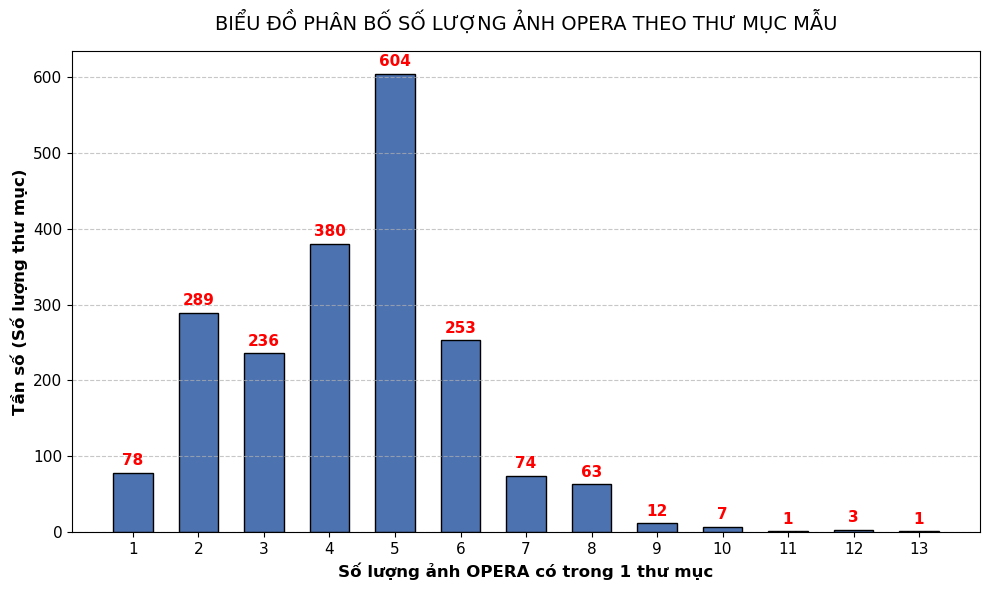

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import pandas as pd

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
# Thư mục gốc chứa các dữ liệu ảnh
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

# Nơi lưu biểu đồ và file thống kê
OUTPUT_CHART = Path("/mnt/hdd12tb/code/thucnd/OPERA_distribution_chart.png")
OUTPUT_CSV = Path("/mnt/hdd12tb/code/thucnd/OPERA_distribution_stats.csv")

# ==========================================
# 2. XỬ LÝ THỐNG KÊ
# ==========================================
if __name__ == "__main__":
    print("==================================================")
    print(" ĐANG THỐNG KÊ SỐ LƯỢNG ẢNH OPERA TRONG TỪNG THƯ MỤC ")
    print("==================================================")
    
    # Bước 1: Tìm tất cả các thư mục con có chứa ít nhất 1 file .tif (thư mục mẫu)
    # Lấy parent của tất cả file .tif để tìm ra các thư mục lưu mẫu
    sample_folders = set(f.parent for f in PAIRS_DIR.rglob("*.tif"))
    print(f"-> Tìm thấy tổng cộng {len(sample_folders)} thư mục mẫu dữ liệu.")
    
    # Bước 2: Đếm số lượng ảnh OPERA trong từng thư mục
    folder_counts = []
    folder_details = []
    
    print("-> Đang đếm ảnh OPERA...")
    for folder in sample_folders:
        # Tìm các file OPERA theo đuôi _OP_..._VVVH_aligned.tif
        opera_files = list(folder.glob("*_OP_*_VVVH_aligned.tif"))
        count = len(opera_files)
        
        folder_counts.append(count)
        folder_details.append({"Folder_Name": folder.name, "OPERA_Count": count})
        
    # Bước 3: Tính tần số (Bao nhiêu thư mục có 1 ảnh, bao nhiêu có 2 ảnh...)
    freq = Counter(folder_counts)
    
    # Sắp xếp trục X theo thứ tự số lượng ảnh tăng dần (0, 1, 2, 3...)
    x_vals = sorted(freq.keys())
    y_vals = [freq[x] for x in x_vals]
    
    # In kết quả ra màn hình
    print("\n[BẢNG TẦN SỐ]")
    for x, y in zip(x_vals, y_vals):
        print(f" - Có {y} thư mục chứa đúng {x} ảnh OPERA")

    # Lưu chi tiết ra file CSV để làm báo cáo
    df = pd.DataFrame(folder_details)
    df.to_csv(OUTPUT_CSV, index=False)
    
    # ==========================================
    # 3. VẼ BIỂU ĐỒ (MATPLOTLIB)
    # ==========================================
    print("\n-> Đang vẽ và lưu biểu đồ...")
    plt.figure(figsize=(10, 6)) # Kích thước biểu đồ
    
    # Vẽ biểu đồ cột
    bars = plt.bar(x_vals, y_vals, color='#4C72B0', edgecolor='black', width=0.6)
    
    # Trang trí trục và tiêu đề
    plt.xlabel('Số lượng ảnh OPERA có trong 1 thư mục', fontsize=12, fontweight='bold')
    plt.ylabel('Tần số (Số lượng thư mục)', fontsize=12, fontweight='bold')
    plt.title('BIỂU ĐỒ PHÂN BỐ SỐ LƯỢNG ẢNH OPERA THEO THƯ MỤC MẪU', fontsize=14, pad=15)
    
    # Ép trục X chỉ hiển thị số nguyên
    plt.xticks(x_vals, fontsize=11)
    plt.yticks(fontsize=11)
    
    # Viết con số cụ thể lên đỉnh của từng cột
    for bar in bars:
        yval = bar.get_height()
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2, yval + (max(y_vals)*0.01), 
                     int(yval), ha='center', va='bottom', fontsize=11, fontweight='bold', color='red')
    
    # Thêm lưới kẻ ngang cho dễ nhìn
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Căn lề và Lưu ra file ảnh
    plt.tight_layout()
    plt.savefig(OUTPUT_CHART, dpi=300) # Lưu với chất lượng cao (300 DPI) để nhét vào slide/báo cáo
    
    print(f" HOÀN THÀNH!")
    print(f"  Biểu đồ đã được lưu tại : {OUTPUT_CHART}")
    print(f"  Dữ liệu CSV lưu tại     : {OUTPUT_CSV}")

In [ ]:
from pathlib import Path
import pandas as pd

# 1. CẤU HÌNH ĐƯỜNG DẪN
# Thư mục gốc chứa các tập train, val, test
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

# Các tập dữ liệu cần đếm
SPLITS = ['train', 'val', 'test']

# 2. XỬ LÝ ĐẾM FILE
if __name__ == "__main__":
    print("=========================================================")
    print(" ĐANG ĐẾM SỐ LƯỢNG ẢNH TRONG CÁC TẬP DỮ LIỆU. VUI LÒNG ĐỢI...")
    print("=========================================================\n")
    
    results = []
    
    for split in SPLITS:
        split_dir = PAIRS_DIR / split
        
        if not split_dir.exists():
            print(f" Cảnh báo: Không tìm thấy thư mục {split_dir}")
            continue
            
        # Tìm tất cả các file HLS và OPERA trong tập hiện tại
        hls_files = list(split_dir.rglob("*_HLS_*_RGB_aligned.tif"))
        opera_files = list(split_dir.rglob("*_OP_*_VVVH_aligned.tif"))
        
        # Đếm số lượng
        hls_count = len(hls_files)
        opera_count = len(opera_files)
        
        # Đếm số lượng thư mục mẫu (mỗi thư mục là 1 cặp mốc tọa độ/thời gian)
        # Sử dụng set() để lọc trùng lặp các thư mục cha
        sample_folders = set(f.parent for f in split_dir.rglob("*.tif"))
        sample_count = len(sample_folders)
        
        results.append({
            "Tập (Split)": split.upper(),
            "Số mẫu (Folders)": sample_count,
            "Số ảnh HLS (Optical)": hls_count,
            "Số ảnh OPERA (SAR)": opera_count
        })

    # 3. HIỂN THỊ BẢNG KẾT QUẢ
    if results:
        df = pd.DataFrame(results)
        
        # Thêm một dòng "Tổng cộng" ở dưới cùng để tiện theo dõi
        total_row = df.sum(numeric_only=True)
        total_row['Tập (Split)'] = 'TỔNG CỘNG'
        df.loc[len(df)] = total_row
        
        print(" BẢNG THỐNG KÊ SỐ LƯỢNG DỮ LIỆU ĐÃ TẢI ".center(57, ' '))
        print("-" * 57)
        print(df.to_string(index=False))
        print("-" * 57)

 ĐANG ĐẾM SỐ LƯỢNG ẢNH TRONG CÁC TẬP DỮ LIỆU. VUI LÒNG ĐỢI...

          BẢNG THỐNG KÊ SỐ LƯỢNG DỮ LIỆU ĐÃ TẢI          
---------------------------------------------------------
Tập (Split)  Số mẫu (Folders)  Số ảnh HLS (Optical)  Số ảnh OPERA (SAR)
      TRAIN              1601                  1601                6890
        VAL               183                   183                 821
       TEST               217                   217                 971
  TỔNG CỘNG              2001                  2001                8682
---------------------------------------------------------


In [7]:
# ==============================================================================
# CELL 1: THỐNG KÊ TỔNG HỢP VÀ HISTOGRAM TRÊN 5% DATASET (OPERA SAR)
# ==============================================================================
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# 1. Cấu hình đường dẫn
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

print("Đang tìm kiếm toàn bộ ảnh OPERA...")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))
total_files = len(all_opera_files)

# Tính toán 5% số lượng ảnh
sample_size = max(1, int(total_files ))
print(f"Tổng số ảnh: {total_files}. Tiến hành lấy mẫu ngẫu nhiên 5% ({sample_size} ảnh).")

# Lấy ngẫu nhiên 5%
random.seed(42) # Cố định seed để kết quả ổn định qua các lần chạy
sample_files = random.sample(all_opera_files, sample_size)

# 2. Gom dữ liệu pixel (Bỏ qua NaN)
vv_pixels_list = []
vh_pixels_list = []

print("Đang đọc và trích xuất pixel...")
for f in tqdm(sample_files, desc="Đọc ảnh"):
    try:
        with rasterio.open(f) as src:
            vv = src.read(1)
            vh = src.read(2)
            vv_pixels_list.append(vv[~np.isnan(vv)])
            vh_pixels_list.append(vh[~np.isnan(vh)])
    except Exception as e:
        pass

# Nối tất cả các mảng pixel lại thành 1 mảng 1D khổng lồ
vv_all = np.concatenate(vv_pixels_list)
vh_all = np.concatenate(vh_pixels_list)

# 3. Tính toán các chỉ số thống kê (Proof)
def print_stats(name, arr):
    print(f"\n--- THỐNG KÊ KÊNH {name} (Trên {len(arr):,} pixels hợp lệ) ---")
    print(f"  Min (Tuyệt đối) : {np.min(arr):.6f}")
    print(f"  Max (Tuyệt đối) : {np.max(arr):.6f}")
    print(f"  Mean (Trung bình): {np.mean(arr):.6f}")
    print(f"  Std (Độ lệch chuẩn): {np.std(arr):.6f}")
    print(f"  Quantiles:")
    print(f"     1% (P1)   : {np.percentile(arr, 1):.6f}")
    print(f"     5% (P5)   : {np.percentile(arr, 5):.6f}")
    print(f"    25% (Q1)   : {np.percentile(arr, 25):.6f}")
    print(f"    50% (Med)  : {np.percentile(arr, 50):.6f}")
    print(f"    75% (Q3)   : {np.percentile(arr, 75):.6f}")
    print(f"    95% (P95)  : {np.percentile(arr, 95):.6f}")
    print(f"    99% (P99)  : {np.percentile(arr, 99):.6f}")

print_stats("VV (Linear Power)", vv_all)
print_stats("VH (Linear Power)", vh_all)

# 4. Vẽ Histogram
p1_vv, p99_vv = np.percentile(vv_all, 1), np.percentile(vv_all, 99)
p1_vh, p99_vh = np.percentile(vh_all, 1), np.percentile(vh_all, 99)

plt.figure(figsize=(14, 6))

# Histogram kênh VV
plt.subplot(1, 2, 1)
plt.hist(vv_all, bins=100, range=(p1_vv, p99_vv), color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Histogram VV (Đã cắt 1%-99%)', fontsize=12, fontweight='bold')
plt.xlabel('Linear Power')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram kênh VH
plt.subplot(1, 2, 2)
plt.hist(vh_all, bins=100, range=(p1_vh, p99_vh), color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Histogram VH (Đã cắt 1%-99%)', fontsize=12, fontweight='bold')
plt.xlabel('Linear Power')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Đang tìm kiếm toàn bộ ảnh OPERA...
Tổng số ảnh: 8682. Tiến hành lấy mẫu ngẫu nhiên 5% (8682 ảnh).
Đang đọc và trích xuất pixel...


Đọc ảnh: 100%|██████████| 8682/8682 [02:23<00:00, 60.65it/s]



--- THỐNG KÊ KÊNH VV (Linear Power) (Trên 3,903,206,007 pixels hợp lệ) ---
  Min (Tuyệt đối) : 0.000000
  Max (Tuyệt đối) : 6496.131836
  Mean (Trung bình): 0.209605
  Std (Độ lệch chuẩn): 1.461828
  Quantiles:
     1% (P1)   : 0.003680


KeyboardInterrupt: 

Đang tìm kiếm toàn bộ ảnh OPERA...
Tổng số ảnh: 8682. Tiến hành lấy mẫu ngẫu nhiên 5% (434 ảnh).
Đang đọc và trích xuất pixel...


Đọc ảnh: 100%|██████████| 434/434 [00:08<00:00, 50.61it/s]



--- THỐNG KÊ KÊNH VV (Linear Power) (Trên 195,035,966 pixels hợp lệ) ---
  Min (Tuyệt đối) : 0.000000
  Max (Tuyệt đối) : 4331.869141
  Mean (Trung bình): 0.208269
  Std (Độ lệch chuẩn): 1.293279
  Quantiles:
     1% (P1)   : 0.004158
     5% (P5)   : 0.016592
    25% (Q1)   : 0.100306
    50% (Med)  : 0.161934
    75% (Q3)   : 0.238166
    95% (P95)  : 0.439462
    99% (P99)  : 0.934874

--- THỐNG KÊ KÊNH VH (Linear Power) (Trên 195,035,456 pixels hợp lệ) ---
  Min (Tuyệt đối) : 0.000000
  Max (Tuyệt đối) : 766.225708
  Mean (Trung bình): 0.043580
  Std (Độ lệch chuẩn): 0.159095
  Quantiles:
     1% (P1)   : 0.000522
     5% (P5)   : 0.001960
    25% (Q1)   : 0.022284
    50% (Med)  : 0.037333
    75% (Q3)   : 0.055139
    95% (P95)  : 0.095158
    99% (P99)  : 0.166017


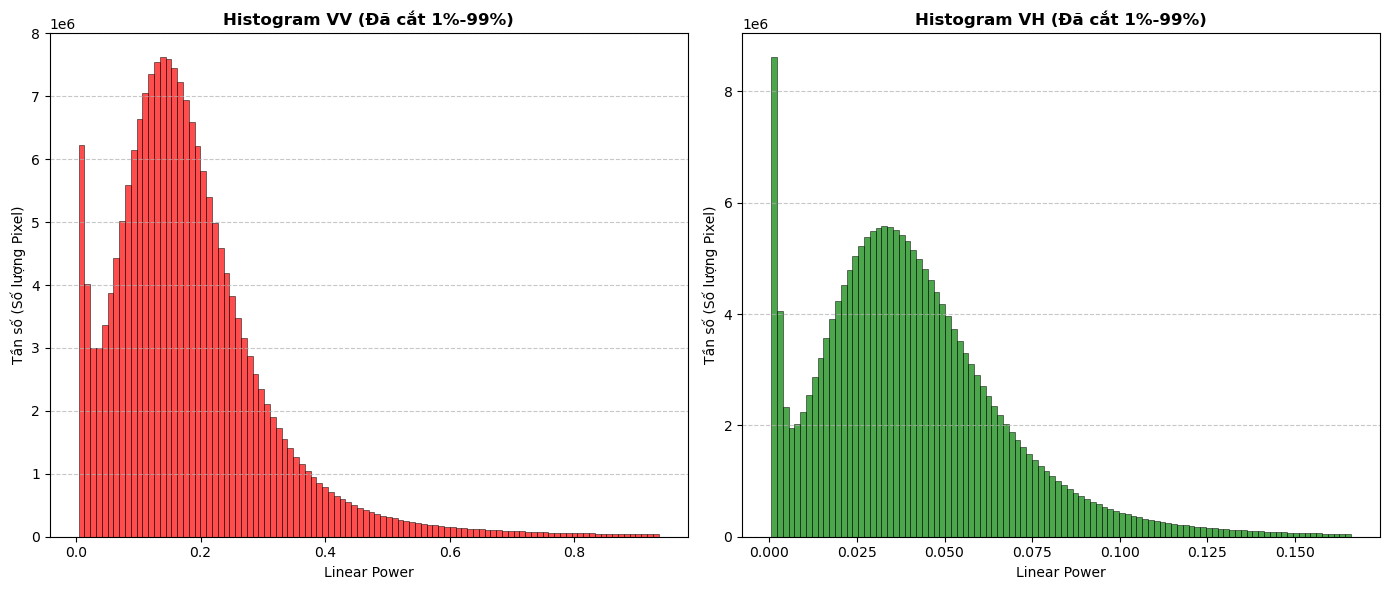

In [ ]:
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# 1. Cấu hình đường dẫn
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

print("Đang tìm kiếm toàn bộ ảnh OPERA...")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))
total_files = len(all_opera_files)

# Tính toán 5% số lượng ảnh
sample_size = max(1, int(total_files * 0.05))
print(f"Tổng số ảnh: {total_files}. Tiến hành lấy mẫu ngẫu nhiên 5% ({sample_size} ảnh).")

# Lấy ngẫu nhiên 5%
random.seed(42) # Cố định seed để kết quả ổn định qua các lần chạy
sample_files = random.sample(all_opera_files, sample_size)

# 2. Gom dữ liệu pixel (Bỏ qua NaN)
vv_pixels_list = []
vh_pixels_list = []

print("Đang đọc và trích xuất pixel...")
for f in tqdm(sample_files, desc="Đọc ảnh"):
    try:
        with rasterio.open(f) as src:
            vv = src.read(1)
            vh = src.read(2)
            vv_pixels_list.append(vv[~np.isnan(vv)])
            vh_pixels_list.append(vh[~np.isnan(vh)])
    except Exception as e:
        pass

# Nối tất cả các mảng pixel lại thành 1 mảng 1D khổng lồ
vv_all = np.concatenate(vv_pixels_list)
vh_all = np.concatenate(vh_pixels_list)

# 3. Tính toán các chỉ số thống kê (Proof)
def print_stats(name, arr):
    print(f"\n--- THỐNG KÊ KÊNH {name} (Trên {len(arr):,} pixels hợp lệ) ---")
    print(f"  Min (Tuyệt đối) : {np.min(arr):.6f}")
    print(f"  Max (Tuyệt đối) : {np.max(arr):.6f}")
    print(f"  Mean (Trung bình): {np.mean(arr):.6f}")
    print(f"  Std (Độ lệch chuẩn): {np.std(arr):.6f}")
    print(f"  Quantiles:")
    print(f"     1% (P1)   : {np.percentile(arr, 1):.6f}")
    print(f"     5% (P5)   : {np.percentile(arr, 5):.6f}")
    print(f"    25% (Q1)   : {np.percentile(arr, 25):.6f}")
    print(f"    50% (Med)  : {np.percentile(arr, 50):.6f}")
    print(f"    75% (Q3)   : {np.percentile(arr, 75):.6f}")
    print(f"    95% (P95)  : {np.percentile(arr, 95):.6f}")
    print(f"    99% (P99)  : {np.percentile(arr, 99):.6f}")

print_stats("VV (Linear Power)", vv_all)
print_stats("VH (Linear Power)", vh_all)

# 4. Vẽ Histogram
p1_vv, p99_vv = np.percentile(vv_all, 1), np.percentile(vv_all, 99)
p1_vh, p99_vh = np.percentile(vh_all, 1), np.percentile(vh_all, 99)

plt.figure(figsize=(14, 6))

# Histogram kênh VV
plt.subplot(1, 2, 1)
plt.hist(vv_all, bins=100, range=(p1_vv, p99_vv), color='red', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Histogram VV (Đã cắt 1%-99%)', fontsize=12, fontweight='bold')
plt.xlabel('Linear Power')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram kênh VH
plt.subplot(1, 2, 2)
plt.hist(vh_all, bins=100, range=(p1_vh, p99_vh), color='green', alpha=0.7, edgecolor='black', linewidth=0.5)
plt.title('Histogram VH (Đã cắt 1%-99%)', fontsize=12, fontweight='bold')
plt.xlabel('Linear Power')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


ẢNH #1: C-49-15-A-a-1_2023-03-08_HLS_2023-03-08_OP_2023-03-12_VVVH_aligned.tif
Thư mục : C-49-15-A-a-1_2023-03-08
[Kênh VV] Min: 0.001454 | Max: 413.277130 | Mean: 0.207457 | P99: 1.469121
[Kênh VH] Min: 0.000000 | Max: 14.084886 | Mean: 0.031589 | P99: 0.144244


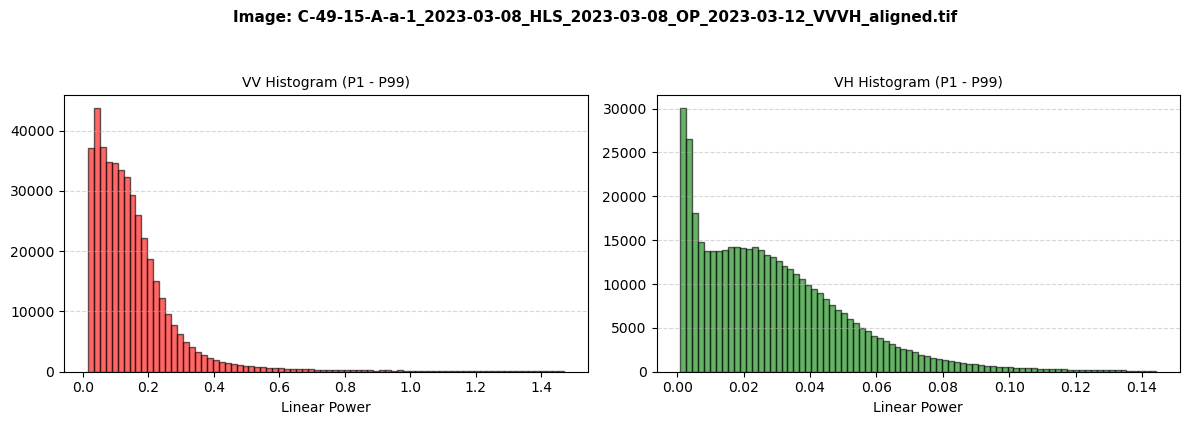


ẢNH #2: C-48-35-D-b-1_2021-04-07_HLS_2021-04-07_OP_2021-04-15_VVVH_aligned.tif
Thư mục : C-48-35-D-b-1_2021-04-07
[Kênh VV] Min: 0.003041 | Max: 195.337036 | Mean: 0.223996 | P99: 0.629286
[Kênh VH] Min: 0.000211 | Max: 12.106942 | Mean: 0.052019 | P99: 0.142500


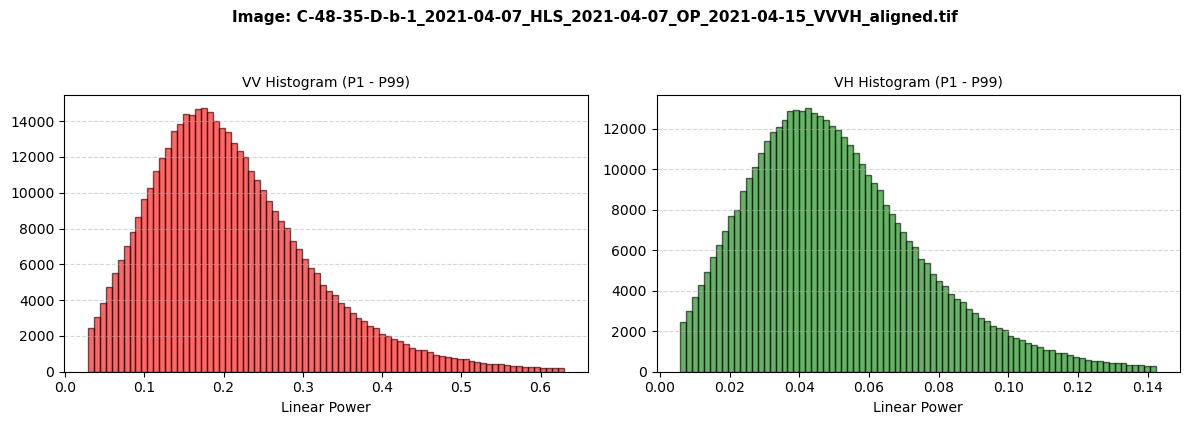


ẢNH #3: D-49-62-A-c-1_2024-04-06_HLS_2024-04-06_OP_2024-04-19_VVVH_aligned.tif
Thư mục : D-49-62-A-c-1_2024-04-06
[Kênh VV] Min: 0.001044 | Max: 52.249737 | Mean: 0.176058 | P99: 0.572919
[Kênh VH] Min: 0.000034 | Max: 6.065797 | Mean: 0.043016 | P99: 0.133241


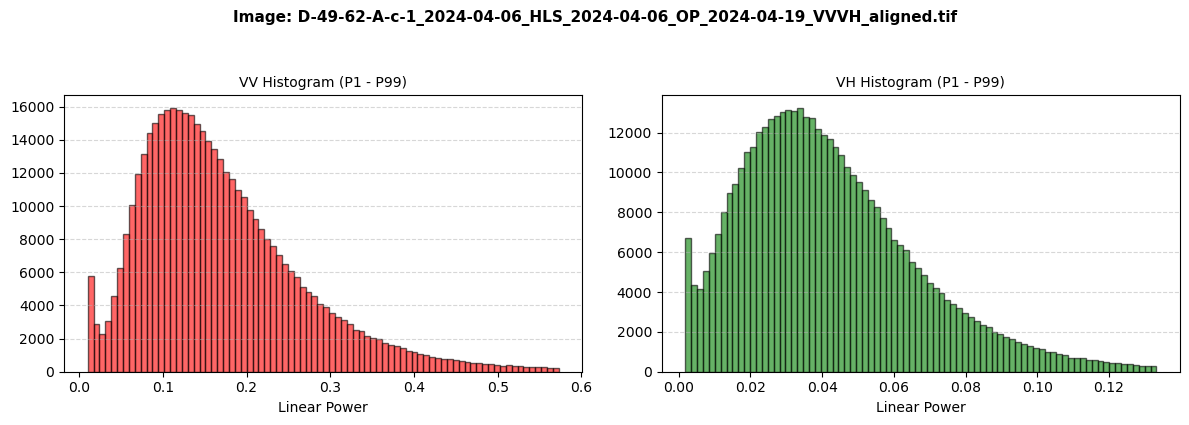


ẢNH #4: D-48-47-D-b-4_2023-11-18_HLS_2023-11-21_OP_2023-11-12_VVVH_aligned.tif
Thư mục : D-48-47-D-b-4_2023-11-18
[Kênh VV] Min: 0.002604 | Max: 25.865103 | Mean: 0.250497 | P99: 0.833562
[Kênh VH] Min: 0.000321 | Max: 1.063093 | Mean: 0.055106 | P99: 0.172782


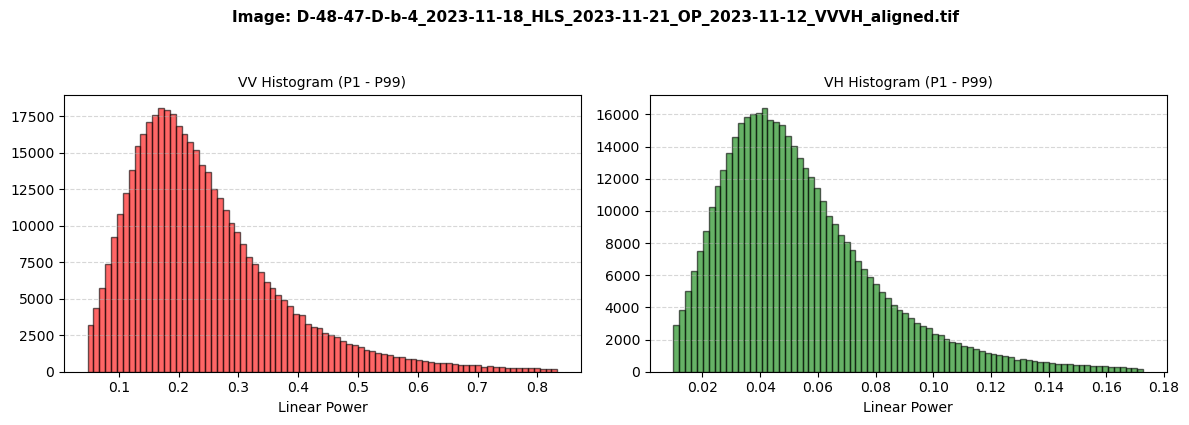


ẢNH #5: C-48-56-B-a-2_2022-01-15_HLS_2021-12-31_OP_2021-12-16_VVVH_aligned.tif
Thư mục : C-48-56-B-a-2_2022-01-15
[Kênh VV] Min: 0.000614 | Max: 225.265656 | Mean: 0.126895 | P99: 0.509225
[Kênh VH] Min: 0.000014 | Max: 10.778619 | Mean: 0.035658 | P99: 0.107648


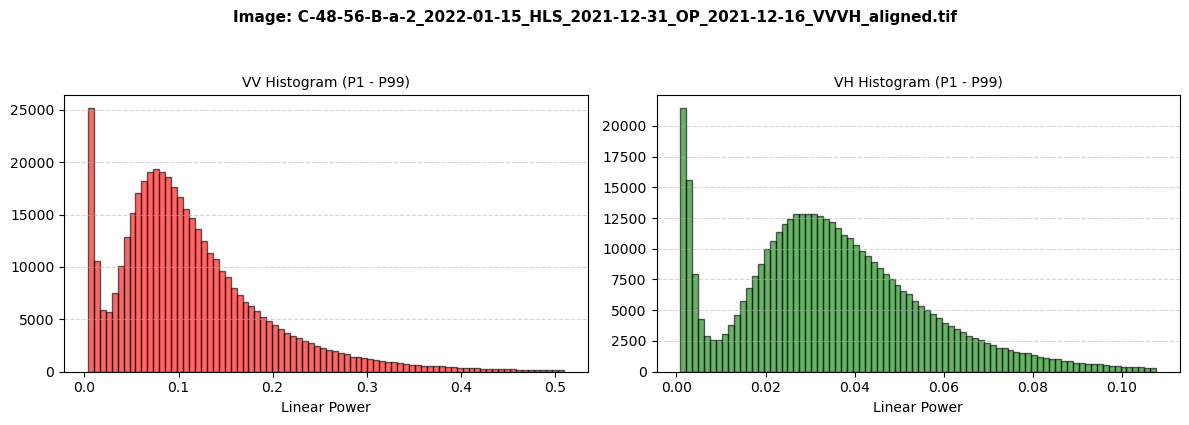

In [4]:
# CELL 2: PHÂN TÍCH CHI TIẾT 5 BỨC ẢNH OPERA NGẪU NHIÊN (MIN, MAX, HISTOGRAM)
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))

# Lấy ngẫu nhiên 5 bức ảnh
random.seed(42) 
sample_5_files = random.sample(all_opera_files, 5)

for i, file_path in enumerate(sample_5_files):
    print(f"\n================================================================")
    print(f"ẢNH #{i+1}: {file_path.name}")
    print(f"Thư mục : {file_path.parent.name}")
    print(f"================================================================")
    
    try:
        with rasterio.open(file_path) as src:
            vv = src.read(1)
            vh = src.read(2)
            
            # Lọc bỏ rác NaN
            valid_vv = vv[~np.isnan(vv)]
            valid_vh = vh[~np.isnan(vh)]
            
            if valid_vv.size == 0 or valid_vh.size == 0:
                print(" Ảnh toàn bộ là NaN, bỏ qua.")
                continue
            
            # In thống kê nhanh
            print(f"[Kênh VV] Min: {np.min(valid_vv):.6f} | Max: {np.max(valid_vv):.6f} | Mean: {np.mean(valid_vv):.6f} | P99: {np.percentile(valid_vv, 99):.6f}")
            print(f"[Kênh VH] Min: {np.min(valid_vh):.6f} | Max: {np.max(valid_vh):.6f} | Mean: {np.mean(valid_vh):.6f} | P99: {np.percentile(valid_vh, 99):.6f}")
            
            # Giới hạn mốc vẽ Histogram (Tránh nhiễu Speckle cực đại làm hỏng biểu đồ)
            vv_min, vv_max = np.percentile(valid_vv, 1), np.percentile(valid_vv, 99)
            vh_min, vh_max = np.percentile(valid_vh, 1), np.percentile(valid_vh, 99)
            
            # Khởi tạo bảng vẽ
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Image: {file_path.name}", fontsize=11, fontweight='bold', y=1.05)
            
            # Vẽ Histogram VV
            axs[0].hist(valid_vv, bins=80, range=(vv_min, vv_max), color='red', alpha=0.6, edgecolor='black')
            axs[0].set_title(f'VV Histogram (P1 - P99)', fontsize=10)
            axs[0].set_xlabel('Linear Power')
            axs[0].grid(axis='y', linestyle='--', alpha=0.5)
            
            # Vẽ Histogram VH
            axs[1].hist(valid_vh, bins=80, range=(vh_min, vh_max), color='green', alpha=0.6, edgecolor='black')
            axs[1].set_title(f'VH Histogram (P1 - P99)', fontsize=10)
            axs[1].set_xlabel('Linear Power')
            axs[1].grid(axis='y', linestyle='--', alpha=0.5)
            
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"❌ Lỗi khi đọc ảnh: {e}")

Đang tìm kiếm toàn bộ ảnh OPERA...
Tổng số ảnh: 8682. Tiến hành lấy mẫu ngẫu nhiên 5% (434 ảnh).
Đang đọc ảnh, lọc NaN và chuyển đổi sang Decibel...


Xử lý ảnh: 100%|██████████| 434/434 [00:08<00:00, 52.06it/s]



--- THỐNG KÊ TOÀN CỤC KÊNH VV (Decibel) (Trên 195,035,966 pixels) ---
  Min (Tuyệt đối) : -70.00 dB
  Max (Tuyệt đối) : 36.37 dB
  Mean (Trung bình): -8.65 dB
  Std (Độ lệch chuẩn): 4.33 dB
  Quantiles:
     1% (P1)   : -23.81 dB
     5% (P5)   : -17.80 dB
    25% (Q1)   : -9.99 dB
    50% (Med)  : -7.91 dB
    75% (Q3)   : -6.23 dB
    95% (P95)  : -3.57 dB
    99% (P99)  : -0.29 dB

--- THỐNG KÊ TOÀN CỤC KÊNH VH (Decibel) (Trên 195,035,456 pixels) ---
  Min (Tuyệt đối) : -70.00 dB
  Max (Tuyệt đối) : 28.84 dB
  Mean (Trung bình): -15.40 dB
  Std (Độ lệch chuẩn): 4.89 dB
  Quantiles:
     1% (P1)   : -32.83 dB
     5% (P5)   : -27.08 dB
    25% (Q1)   : -16.52 dB
    50% (Med)  : -14.28 dB
    75% (Q3)   : -12.59 dB
    95% (P95)  : -10.22 dB
    99% (P99)  : -7.80 dB


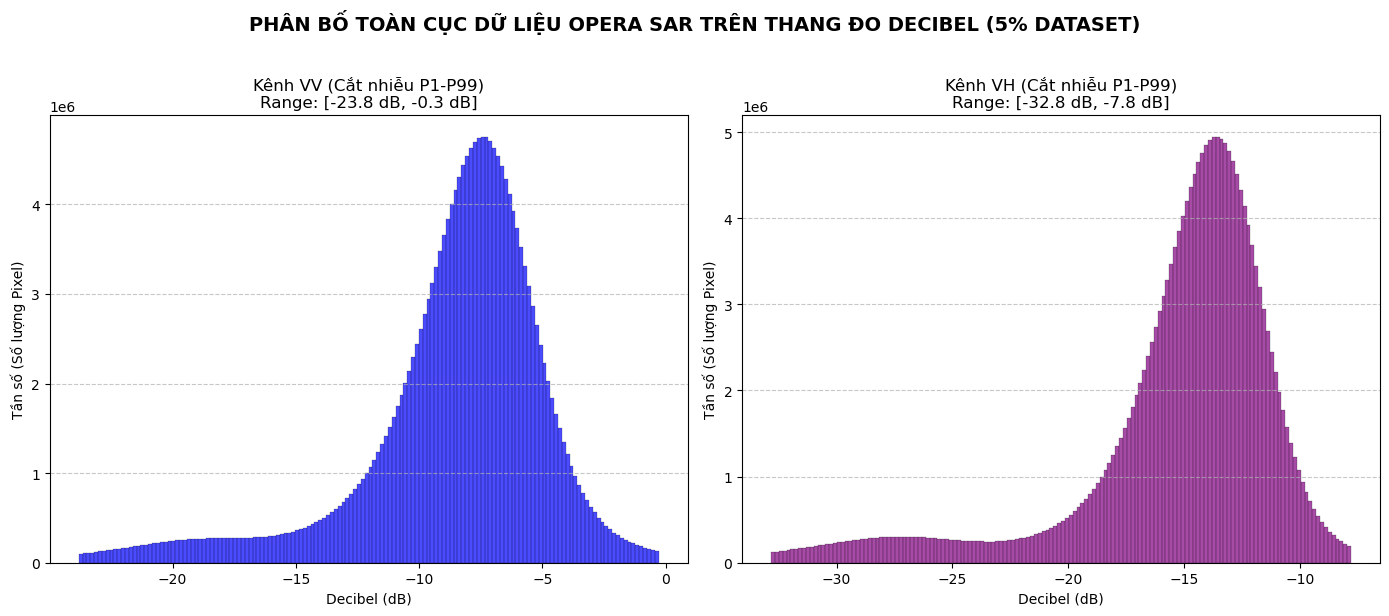

In [9]:

import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# 1. Cấu hình đường dẫn và hàm chuẩn hóa
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

def linear_to_db(arr):
    """ Chuyển đổi Linear Power sang Decibel (dB) chặn dưới ở 1e-7 """
    return 10 * np.log10(np.maximum(arr, 1e-7))

print("Đang tìm kiếm toàn bộ ảnh OPERA...")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))
total_files = len(all_opera_files)

# Tính toán 5% số lượng ảnh
sample_size = max(1, int(total_files * 0.05))
print(f"Tổng số ảnh: {total_files}. Tiến hành lấy mẫu ngẫu nhiên 5% ({sample_size} ảnh).")

# Lấy ngẫu nhiên 5%
random.seed(42) # Cố định seed
sample_files = random.sample(all_opera_files, sample_size)

# 2. Gom dữ liệu pixel và chuyển đổi dB trực tiếp
vv_db_list = []
vh_db_list = []

print("Đang đọc ảnh, lọc NaN và chuyển đổi sang Decibel...")
for f in tqdm(sample_files, desc="Xử lý ảnh"):
    try:
        with rasterio.open(f) as src:
            vv = src.read(1)
            vh = src.read(2)
            
            # Lọc bỏ NaN
            valid_vv = vv[~np.isnan(vv)]
            valid_vh = vh[~np.isnan(vh)]
            
            # Chuyển đổi ngay sang dB và đưa vào list để tối ưu RAM
            if valid_vv.size > 0:
                vv_db_list.append(linear_to_db(valid_vv))
            if valid_vh.size > 0:
                vh_db_list.append(linear_to_db(valid_vh))
    except Exception as e:
        pass

# Nối tất cả các mảng pixel lại thành 1 mảng 1D khổng lồ
vv_db_all = np.concatenate(vv_db_list)
vh_db_all = np.concatenate(vh_db_list)

# 3. Tính toán các chỉ số thống kê toàn cục
def print_stats_db(name, arr):
    print(f"\n--- THỐNG KÊ TOÀN CỤC KÊNH {name} (Trên {len(arr):,} pixels) ---")
    print(f"  Min (Tuyệt đối) : {np.min(arr):.2f} dB")
    print(f"  Max (Tuyệt đối) : {np.max(arr):.2f} dB")
    print(f"  Mean (Trung bình): {np.mean(arr):.2f} dB")
    print(f"  Std (Độ lệch chuẩn): {np.std(arr):.2f} dB")
    print(f"  Quantiles:")
    print(f"     1% (P1)   : {np.percentile(arr, 1):.2f} dB")
    print(f"     5% (P5)   : {np.percentile(arr, 5):.2f} dB")
    print(f"    25% (Q1)   : {np.percentile(arr, 25):.2f} dB")
    print(f"    50% (Med)  : {np.percentile(arr, 50):.2f} dB")
    print(f"    75% (Q3)   : {np.percentile(arr, 75):.2f} dB")
    print(f"    95% (P95)  : {np.percentile(arr, 95):.2f} dB")
    print(f"    99% (P99)  : {np.percentile(arr, 99):.2f} dB")

print_stats_db("VV (Decibel)", vv_db_all)
print_stats_db("VH (Decibel)", vh_db_all)

# 4. Vẽ Histogram tổng hợp
p1_vv, p99_vv = np.percentile(vv_db_all, 1), np.percentile(vv_db_all, 99)
p1_vh, p99_vh = np.percentile(vh_db_all, 1), np.percentile(vh_db_all, 99)

plt.figure(figsize=(14, 6))
plt.suptitle('PHÂN BỐ TOÀN CỤC DỮ LIỆU OPERA SAR TRÊN THANG ĐO DECIBEL (5% DATASET)', fontsize=14, fontweight='bold', y=1.02)

# Histogram kênh VV
plt.subplot(1, 2, 1)
plt.hist(vv_db_all, bins=150, range=(p1_vv, p99_vv), color='blue', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh VV (Cắt nhiễu P1-P99)\nRange: [{p1_vv:.1f} dB, {p99_vv:.1f} dB]', fontsize=12)
plt.xlabel('Decibel (dB)')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram kênh VH
plt.subplot(1, 2, 2)
plt.hist(vh_db_all, bins=150, range=(p1_vh, p99_vh), color='purple', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh VH (Cắt nhiễu P1-P99)\nRange: [{p1_vh:.1f} dB, {p99_vh:.1f} dB]', fontsize=12)
plt.xlabel('Decibel (dB)')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Đang tìm kiếm toàn bộ ảnh OPERA...
Tổng số ảnh: 5979. Tiến hành lấy mẫu ngẫu nhiên 5% (5979 ảnh).
Đang đọc ảnh, lọc NaN và chuyển đổi sang Decibel...


Xử lý ảnh: 100%|██████████| 5979/5979 [00:53<00:00, 110.77it/s]



--- THỐNG KÊ TOÀN CỤC KÊNH VV (Decibel) (Trên 1,251,719,435 pixels) ---
  Min (Tuyệt đối) : -70.00 dB
  Max (Tuyệt đối) : 39.69 dB
  Mean (Trung bình): -8.53 dB
  Std (Độ lệch chuẩn): 4.29 dB
  Quantiles:
     1% (P1)   : -22.86 dB
     5% (P5)   : -17.46 dB
    25% (Q1)   : -10.01 dB
    50% (Med)  : -7.89 dB
    75% (Q3)   : -6.14 dB
    95% (P95)  : -3.24 dB
    99% (P99)  : 0.76 dB

--- THỐNG KÊ TOÀN CỤC KÊNH VH (Decibel) (Trên 1,251,718,549 pixels) ---
  Min (Tuyệt đối) : -70.00 dB
  Max (Tuyệt đối) : 32.95 dB
  Mean (Trung bình): -15.35 dB
  Std (Độ lệch chuẩn): 4.63 dB
  Quantiles:
     1% (P1)   : -31.15 dB
     5% (P5)   : -25.96 dB
    25% (Q1)   : -16.71 dB
    50% (Med)  : -14.39 dB
    75% (Q3)   : -12.62 dB
    95% (P95)  : -10.12 dB
    99% (P99)  : -7.29 dB


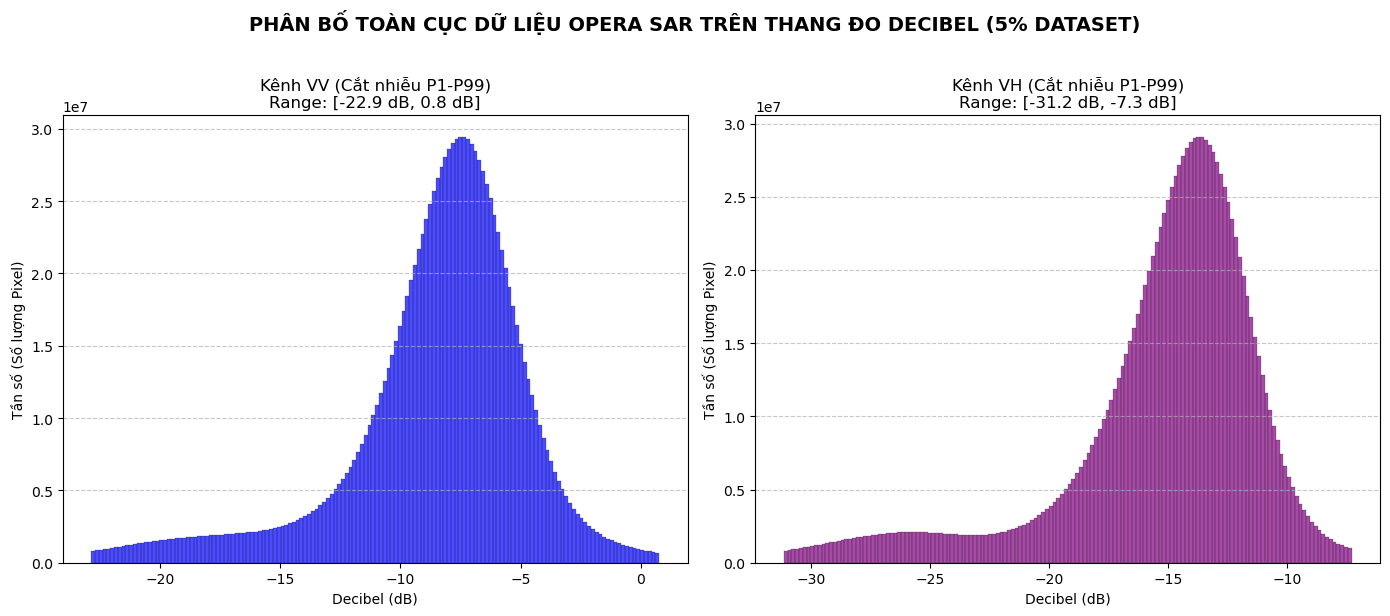

In [1]:

import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# 1. Cấu hình đường dẫn và hàm chuẩn hóa
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs")

def linear_to_db(arr):
    """ Chuyển đổi Linear Power sang Decibel (dB) chặn dưới ở 1e-7 """
    return 10 * np.log10(np.maximum(arr, 1e-7))

print("Đang tìm kiếm toàn bộ ảnh OPERA...")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))
total_files = len(all_opera_files)

# Tính toán 5% số lượng ảnh
sample_size = max(1, int(total_files ))
print(f"Tổng số ảnh: {total_files}. Tiến hành lấy mẫu ngẫu nhiên 5% ({sample_size} ảnh).")

# Lấy ngẫu nhiên 5%
random.seed(42) # Cố định seed
sample_files = random.sample(all_opera_files, sample_size)

# 2. Gom dữ liệu pixel và chuyển đổi dB trực tiếp
vv_db_list = []
vh_db_list = []

print("Đang đọc ảnh, lọc NaN và chuyển đổi sang Decibel...")
for f in tqdm(sample_files, desc="Xử lý ảnh"):
    try:
        with rasterio.open(f) as src:
            vv = src.read(1)
            vh = src.read(2)
            
            # Lọc bỏ NaN
            valid_vv = vv[~np.isnan(vv)]
            valid_vh = vh[~np.isnan(vh)]
            
            # Chuyển đổi ngay sang dB và đưa vào list để tối ưu RAM
            if valid_vv.size > 0:
                vv_db_list.append(linear_to_db(valid_vv))
            if valid_vh.size > 0:
                vh_db_list.append(linear_to_db(valid_vh))
    except Exception as e:
        pass

# Nối tất cả các mảng pixel lại thành 1 mảng 1D khổng lồ
vv_db_all = np.concatenate(vv_db_list)
vh_db_all = np.concatenate(vh_db_list)

# 3. Tính toán các chỉ số thống kê toàn cục
def print_stats_db(name, arr):
    print(f"\n--- THỐNG KÊ TOÀN CỤC KÊNH {name} (Trên {len(arr):,} pixels) ---")
    print(f"  Min (Tuyệt đối) : {np.min(arr):.2f} dB")
    print(f"  Max (Tuyệt đối) : {np.max(arr):.2f} dB")
    print(f"  Mean (Trung bình): {np.mean(arr):.2f} dB")
    print(f"  Std (Độ lệch chuẩn): {np.std(arr):.2f} dB")
    print(f"  Quantiles:")
    print(f"     1% (P1)   : {np.percentile(arr, 1):.2f} dB")
    print(f"     5% (P5)   : {np.percentile(arr, 5):.2f} dB")
    print(f"    25% (Q1)   : {np.percentile(arr, 25):.2f} dB")
    print(f"    50% (Med)  : {np.percentile(arr, 50):.2f} dB")
    print(f"    75% (Q3)   : {np.percentile(arr, 75):.2f} dB")
    print(f"    95% (P95)  : {np.percentile(arr, 95):.2f} dB")
    print(f"    99% (P99)  : {np.percentile(arr, 99):.2f} dB")

print_stats_db("VV (Decibel)", vv_db_all)
print_stats_db("VH (Decibel)", vh_db_all)

# 4. Vẽ Histogram tổng hợp
p1_vv, p99_vv = np.percentile(vv_db_all, 1), np.percentile(vv_db_all, 99)
p1_vh, p99_vh = np.percentile(vh_db_all, 1), np.percentile(vh_db_all, 99)

plt.figure(figsize=(14, 6))
plt.suptitle('PHÂN BỐ TOÀN CỤC DỮ LIỆU OPERA SAR TRÊN THANG ĐO DECIBEL (5% DATASET)', fontsize=14, fontweight='bold', y=1.02)

# Histogram kênh VV
plt.subplot(1, 2, 1)
plt.hist(vv_db_all, bins=150, range=(p1_vv, p99_vv), color='blue', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh VV (Cắt nhiễu P1-P99)\nRange: [{p1_vv:.1f} dB, {p99_vv:.1f} dB]', fontsize=12)
plt.xlabel('Decibel (dB)')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram kênh VH
plt.subplot(1, 2, 2)
plt.hist(vh_db_all, bins=150, range=(p1_vh, p99_vh), color='purple', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh VH (Cắt nhiễu P1-P99)\nRange: [{p1_vh:.1f} dB, {p99_vh:.1f} dB]', fontsize=12)
plt.xlabel('Decibel (dB)')
plt.ylabel('Tần số (Số lượng Pixel)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


ẢNH #1: E-48-8-A-c_2023-11-19_HLS_2023-11-19_OP_2023-12-02_VVVH_aligned.tif
Thư mục : E-48-8-A-c_2023-11-19
[Kênh VV - dB] P1 : -19.25 | Min: -27.54 | Max: 20.66 | Mean: -7.35 | P99: 0.76
[Kênh VH - dB] P1 : -24.91 | Min: -37.63 | Max: 12.75 | Mean: -13.86 | P99: -8.22


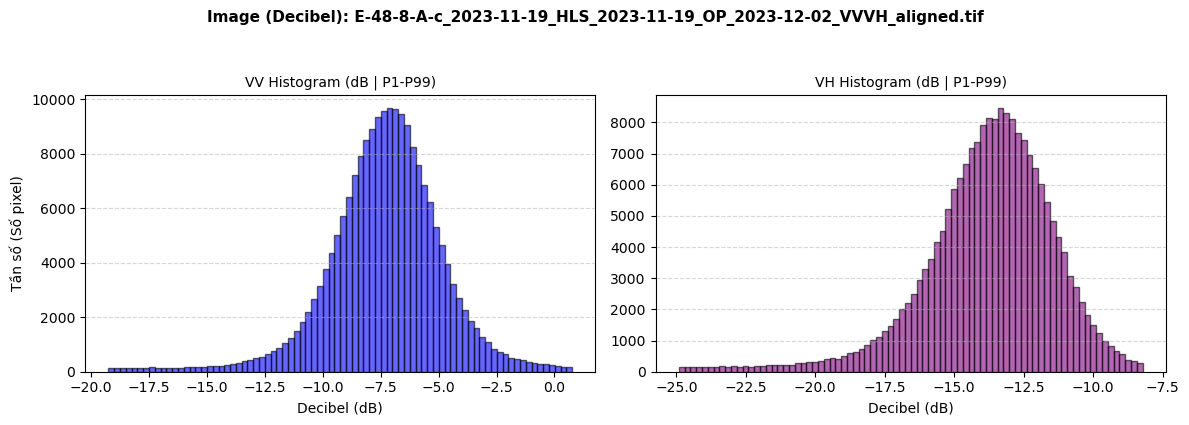


ẢNH #2: E-48-96-B-c_2024-02-21_HLS_2024-03-05_OP_2024-03-02_VVVH_aligned.tif
Thư mục : E-48-96-B-c_2024-02-21
[Kênh VV - dB] P1 : -21.10 | Min: -30.10 | Max: 22.92 | Mean: -10.86 | P99: -1.57
[Kênh VH - dB] P1 : -31.67 | Min: -50.37 | Max: 8.24 | Mean: -18.64 | P99: -8.82


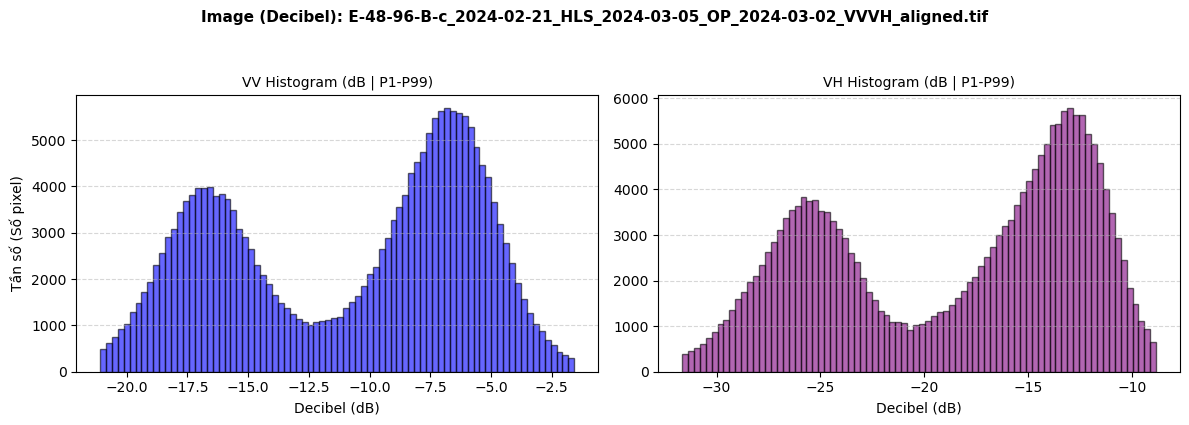


ẢNH #3: E-48-8-B-a_2023-11-19_HLS_2023-11-19_OP_2023-11-20_VVVH_aligned.tif
Thư mục : E-48-8-B-a_2023-11-19
[Kênh VV - dB] P1 : -21.89 | Min: -30.82 | Max: 26.61 | Mean: -8.41 | P99: 0.59
[Kênh VH - dB] P1 : -27.02 | Min: -38.31 | Max: 16.26 | Mean: -15.16 | P99: -7.98


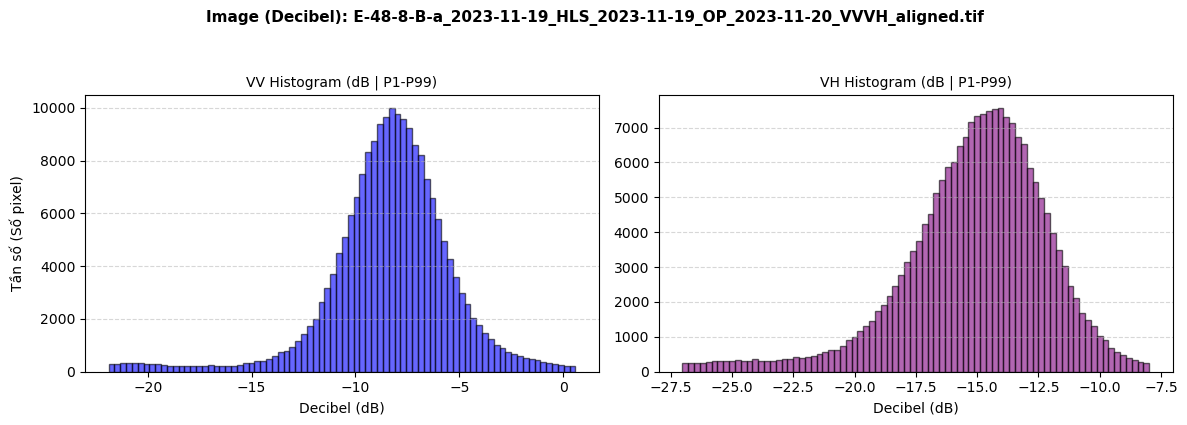


ẢNH #4: E-48-96-D-c_2024-03-05_HLS_2024-02-21_OP_2024-02-28_VVVH_aligned.tif
Thư mục : E-48-96-D-c_2024-03-05
[Kênh VV - dB] P1 : -13.54 | Min: -28.63 | Max: 9.21 | Mean: -6.73 | P99: 0.40
[Kênh VH - dB] P1 : -20.68 | Min: -33.31 | Max: 2.51 | Mean: -13.54 | P99: -6.85


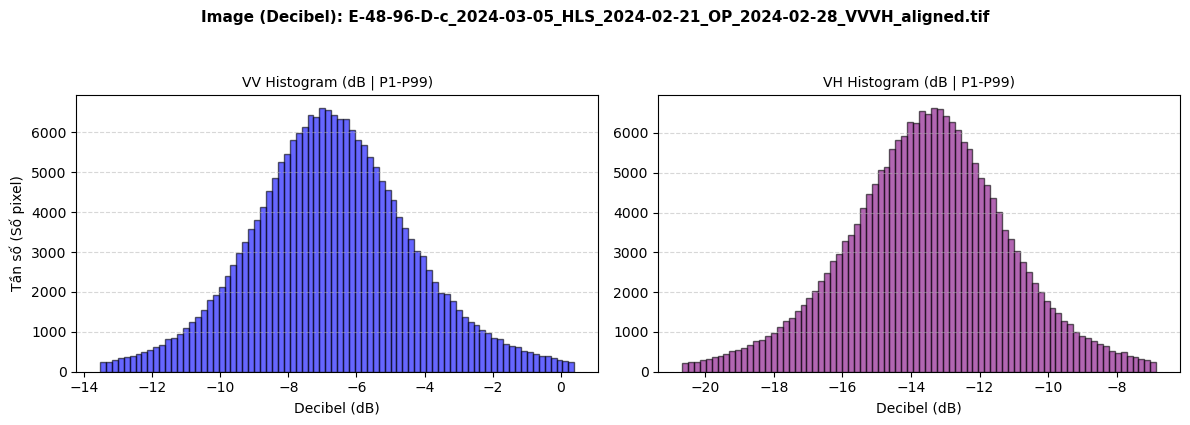


ẢNH #5: E-48-56-B-a_2022-08-23_HLS_2022-08-28_OP_2022-09-02_VVVH_aligned.tif
Thư mục : E-48-56-B-a_2022-08-23
[Kênh VV - dB] P1 : -14.64 | Min: -30.55 | Max: 18.59 | Mean: -7.12 | P99: -0.41
[Kênh VH - dB] P1 : -21.32 | Min: -44.60 | Max: 11.43 | Mean: -13.54 | P99: -7.49


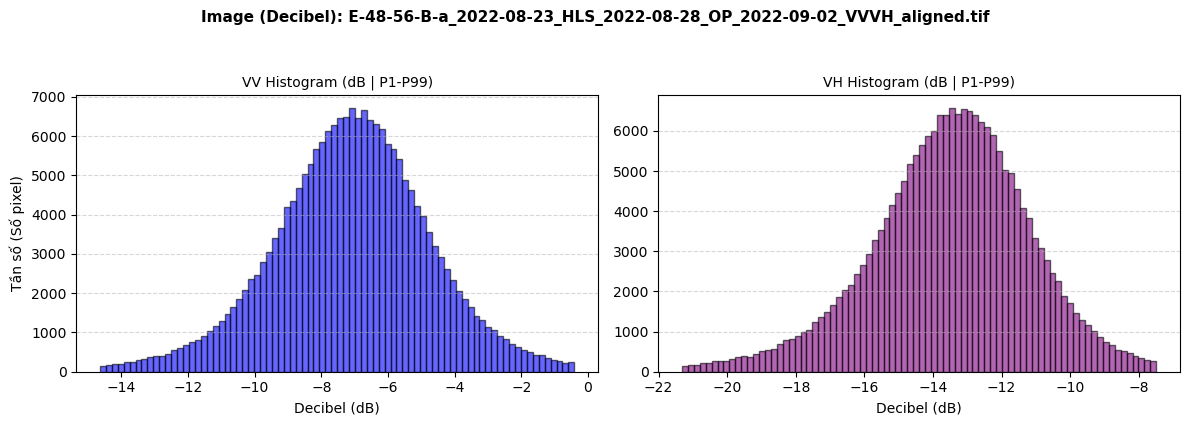

In [4]:
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs")
all_opera_files = list(PAIRS_DIR.rglob("E*_OP_*_VVVH_aligned.tif"))

# Lấy ngẫu nhiên 5 bức ảnh (Đổi seed để lấy 5 ảnh khác Cell 2)
random.seed(41) 
sample_5_files = random.sample(all_opera_files, 5)

def linear_to_db(arr):
    """
    Công thức chuẩn hóa sang dB: 10 * log10(max(Value, 10^-7))
    Sử dụng np.maximum để chặn dưới tất cả các giá trị <= 0 về 1e-7, tránh lỗi log(0)
    """
    return 10 * np.log10(np.maximum(arr, 1e-7))

for i, file_path in enumerate(sample_5_files):
    print(f"\n================================================================")
    print(f"ẢNH #{i+1}: {file_path.name}")
    print(f"Thư mục : {file_path.parent.name}")
    print(f"================================================================")
    
    try:
        with rasterio.open(file_path) as src:
            vv_linear = src.read(1)
            vh_linear = src.read(2)
            
            # 1. Lọc bỏ rác NaN ở hệ Linear
            valid_vv_linear = vv_linear[~np.isnan(vv_linear)]
            valid_vh_linear = vh_linear[~np.isnan(vh_linear)]
            
            if valid_vv_linear.size == 0 or valid_vh_linear.size == 0:
                print("⚠️ Ảnh toàn bộ là NaN, bỏ qua.")
                continue
            
            # 2. CHUYỂN ĐỔI SANG HỆ CƠ SỐ DECIBEL (dB)
            valid_vv_db = linear_to_db(valid_vv_linear)
            valid_vh_db = linear_to_db(valid_vh_linear)
            
            # 3. In thống kê nhanh (Đã chuyển sang thang đo dB)
            print(f"[Kênh VV - dB] P1 : {np.percentile(valid_vv_db, 1):.2f} | Min: {np.min(valid_vv_db):.2f} | Max: {np.max(valid_vv_db):.2f} | Mean: {np.mean(valid_vv_db):.2f} | P99: {np.percentile(valid_vv_db, 99):.2f}")
            print(f"[Kênh VH - dB] P1 : {np.percentile(valid_vh_db, 1):.2f} | Min: {np.min(valid_vh_db):.2f} | Max: {np.max(valid_vh_db):.2f} | Mean: {np.mean(valid_vh_db):.2f} | P99: {np.percentile(valid_vh_db, 99):.2f}")
            
            # 4. Giới hạn mốc vẽ Histogram (Cắt 1% - 99% để loại bỏ nhiễu đốm)
            vv_min, vv_max = np.percentile(valid_vv_db, 1), np.percentile(valid_vv_db, 99)
            vh_min, vh_max = np.percentile(valid_vh_db, 1), np.percentile(valid_vh_db, 99)
            
            # Khởi tạo bảng vẽ
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Image (Decibel): {file_path.name}", fontsize=11, fontweight='bold', y=1.05)
            
            # Vẽ Histogram VV (dB)
            axs[0].hist(valid_vv_db, bins=80, range=(vv_min, vv_max), color='blue', alpha=0.6, edgecolor='black')
            axs[0].set_title(f'VV Histogram (dB | P1-P99)', fontsize=10)
            axs[0].set_xlabel('Decibel (dB)')
            axs[0].set_ylabel('Tần số (Số pixel)')
            axs[0].grid(axis='y', linestyle='--', alpha=0.5)
            
            # Vẽ Histogram VH (dB)
            axs[1].hist(valid_vh_db, bins=80, range=(vh_min, vh_max), color='purple', alpha=0.6, edgecolor='black')
            axs[1].set_title(f'VH Histogram (dB | P1-P99)', fontsize=10)
            axs[1].set_xlabel('Decibel (dB)')
            axs[1].grid(axis='y', linestyle='--', alpha=0.5)
            
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"❌ Lỗi khi đọc ảnh: {e}")


ẢNH #1: F-48-92-C-b_2021-06-17_HLS_2021-06-17_OP_2021-06-03_VVVH_aligned.tif
Thư mục : F-48-92-C-b_2021-06-17
[Kênh VV - dB] P1 : -14.97 | Min: -27.61 | Max: 20.20 | Mean: -7.81 | P99: -1.31
[Kênh VH - dB] P1 : -21.67 | Min: -37.78 | Max: 12.66 | Mean: -13.89 | P99: -7.57


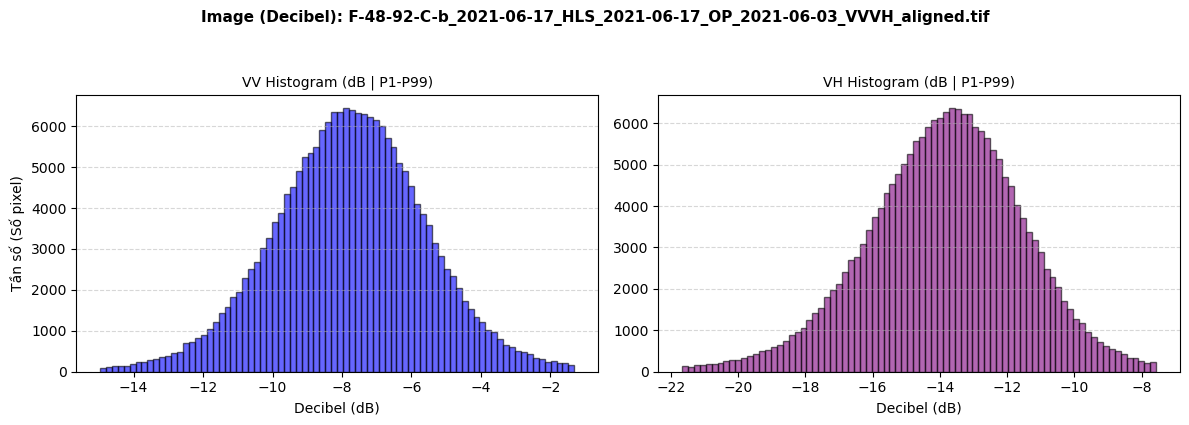


ẢNH #2: C-48-34-A-a_2021-01-07_HLS_2021-01-15_OP_2021-01-14_VVVH_aligned.tif
Thư mục : C-48-34-A-a_2021-01-07
[Kênh VV - dB] P1 : -16.60 | Min: -30.04 | Max: 32.84 | Mean: -7.20 | P99: 4.46
[Kênh VH - dB] P1 : -23.68 | Min: -34.72 | Max: 16.47 | Mean: -14.21 | P99: -5.52


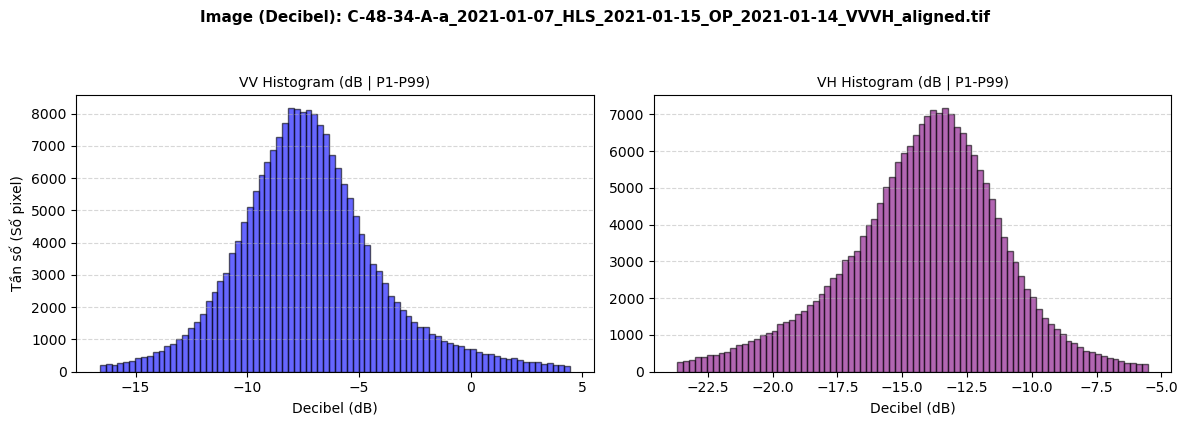


ẢNH #3: C-48-34-C-d_2023-05-02_HLS_2023-05-02_OP_2023-04-18_VVVH_aligned.tif
Thư mục : C-48-34-C-d_2023-05-02
[Kênh VV - dB] P1 : -20.04 | Min: -29.28 | Max: 26.30 | Mean: -9.69 | P99: 1.26
[Kênh VH - dB] P1 : -29.29 | Min: -44.83 | Max: 10.98 | Mean: -17.19 | P99: -8.26


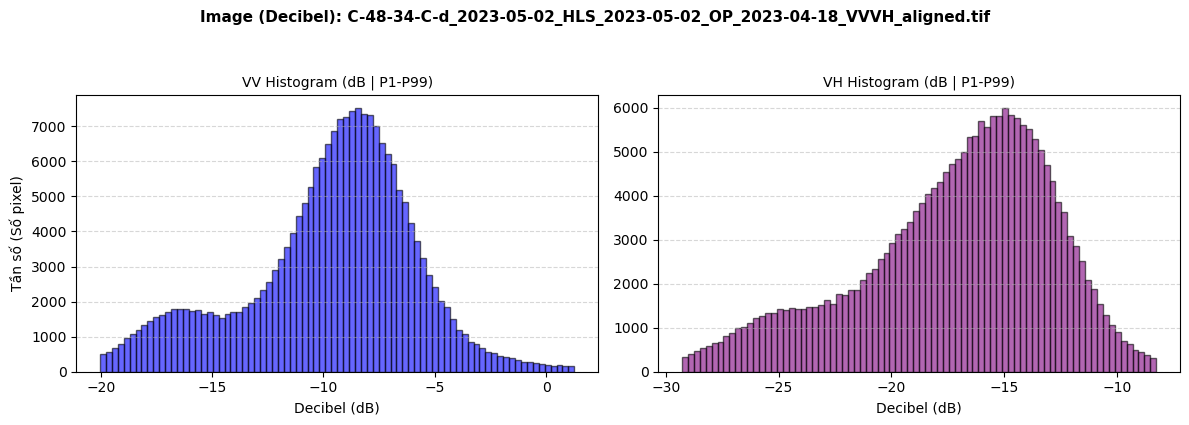


ẢNH #4: D-48-96-C-d_2023-03-08_HLS_2023-03-08_OP_2023-03-12_VVVH_aligned.tif
Thư mục : D-48-96-C-d_2023-03-08
[Kênh VV - dB] P1 : -18.23 | Min: -26.92 | Max: 20.03 | Mean: -9.16 | P99: -2.77
[Kênh VH - dB] P1 : -25.59 | Min: -40.16 | Max: 15.37 | Mean: -15.15 | P99: -9.33


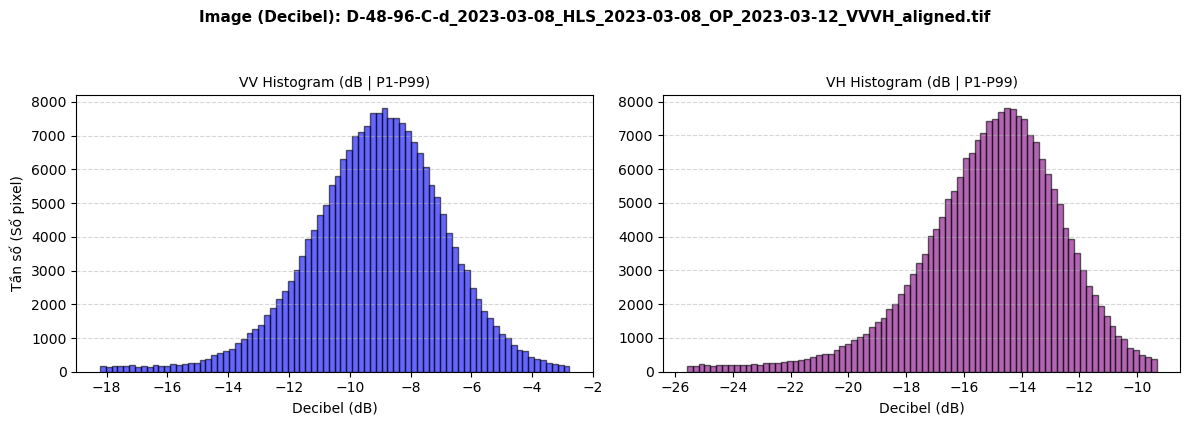


ẢNH #5: F-48-82-B-a_2024-10-11_HLS_2024-10-11_OP_2024-10-16_VVVH_aligned.tif
Thư mục : F-48-82-B-a_2024-10-11
[Kênh VV - dB] P1 : -21.12 | Min: -30.73 | Max: 24.46 | Mean: -9.93 | P99: 3.28
[Kênh VH - dB] P1 : -29.43 | Min: -41.40 | Max: 13.56 | Mean: -16.86 | P99: -6.53


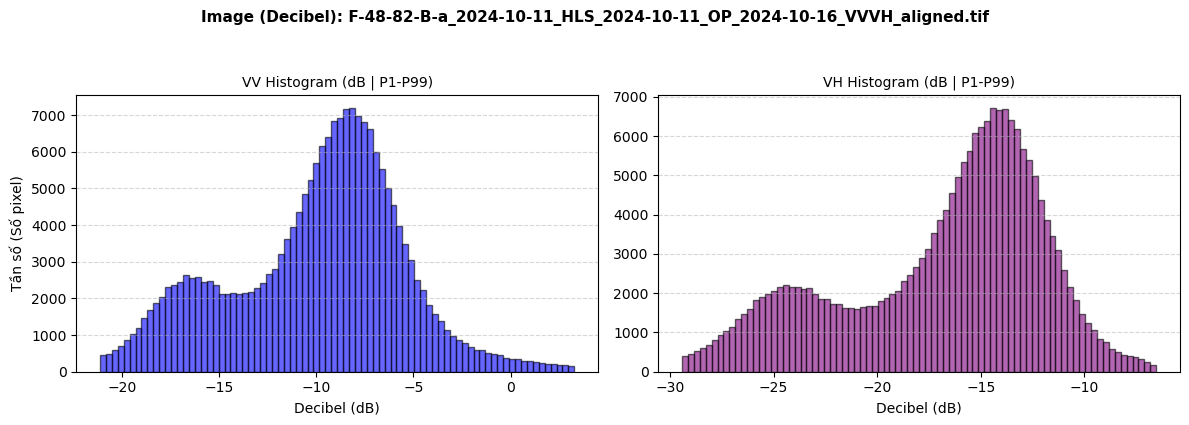

In [5]:
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs")
all_opera_files = list(PAIRS_DIR.rglob("*_OP_*_VVVH_aligned.tif"))

# Lấy ngẫu nhiên 5 bức ảnh (Đổi seed để lấy 5 ảnh khác Cell 2)
random.seed(41) 
sample_5_files = random.sample(all_opera_files, 5)

def linear_to_db(arr):
    """
    Công thức chuẩn hóa sang dB: 10 * log10(max(Value, 10^-7))
    Sử dụng np.maximum để chặn dưới tất cả các giá trị <= 0 về 1e-7, tránh lỗi log(0)
    """
    return 10 * np.log10(np.maximum(arr, 1e-7))

for i, file_path in enumerate(sample_5_files):
    print(f"\n================================================================")
    print(f"ẢNH #{i+1}: {file_path.name}")
    print(f"Thư mục : {file_path.parent.name}")
    print(f"================================================================")
    
    try:
        with rasterio.open(file_path) as src:
            vv_linear = src.read(1)
            vh_linear = src.read(2)
            
            # 1. Lọc bỏ rác NaN ở hệ Linear
            valid_vv_linear = vv_linear[~np.isnan(vv_linear)]
            valid_vh_linear = vh_linear[~np.isnan(vh_linear)]
            
            if valid_vv_linear.size == 0 or valid_vh_linear.size == 0:
                print("⚠️ Ảnh toàn bộ là NaN, bỏ qua.")
                continue
            
            # 2. CHUYỂN ĐỔI SANG HỆ CƠ SỐ DECIBEL (dB)
            valid_vv_db = linear_to_db(valid_vv_linear)
            valid_vh_db = linear_to_db(valid_vh_linear)
            
            # 3. In thống kê nhanh (Đã chuyển sang thang đo dB)
            print(f"[Kênh VV - dB] P1 : {np.percentile(valid_vv_db, 1):.2f} | Min: {np.min(valid_vv_db):.2f} | Max: {np.max(valid_vv_db):.2f} | Mean: {np.mean(valid_vv_db):.2f} | P99: {np.percentile(valid_vv_db, 99):.2f}")
            print(f"[Kênh VH - dB] P1 : {np.percentile(valid_vh_db, 1):.2f} | Min: {np.min(valid_vh_db):.2f} | Max: {np.max(valid_vh_db):.2f} | Mean: {np.mean(valid_vh_db):.2f} | P99: {np.percentile(valid_vh_db, 99):.2f}")
            
            # 4. Giới hạn mốc vẽ Histogram (Cắt 1% - 99% để loại bỏ nhiễu đốm)
            vv_min, vv_max = np.percentile(valid_vv_db, 1), np.percentile(valid_vv_db, 99)
            vh_min, vh_max = np.percentile(valid_vh_db, 1), np.percentile(valid_vh_db, 99)
            
            # Khởi tạo bảng vẽ
            fig, axs = plt.subplots(1, 2, figsize=(12, 4))
            fig.suptitle(f"Image (Decibel): {file_path.name}", fontsize=11, fontweight='bold', y=1.05)
            
            # Vẽ Histogram VV (dB)
            axs[0].hist(valid_vv_db, bins=80, range=(vv_min, vv_max), color='blue', alpha=0.6, edgecolor='black')
            axs[0].set_title(f'VV Histogram (dB | P1-P99)', fontsize=10)
            axs[0].set_xlabel('Decibel (dB)')
            axs[0].set_ylabel('Tần số (Số pixel)')
            axs[0].grid(axis='y', linestyle='--', alpha=0.5)
            
            # Vẽ Histogram VH (dB)
            axs[1].hist(valid_vh_db, bins=80, range=(vh_min, vh_max), color='purple', alpha=0.6, edgecolor='black')
            axs[1].set_title(f'VH Histogram (dB | P1-P99)', fontsize=10)
            axs[1].set_xlabel('Decibel (dB)')
            axs[1].grid(axis='y', linestyle='--', alpha=0.5)
            
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"❌ Lỗi khi đọc ảnh: {e}")

Đang tìm kiếm toàn bộ ảnh HLS...
Tổng số ảnh HLS: 2001. Tiến hành lấy mẫu ngẫu nhiên 5% (100 ảnh).
Đang đọc ảnh HLS và trích xuất pixel RGB...


Xử lý ảnh HLS: 100%|██████████| 100/100 [00:03<00:00, 30.67it/s]



--- THỐNG KÊ KÊNH B04 (RED) (Trên 44,990,014 pixels) ---
  Min (Tuyệt đối) : -1120.000000
  Max (Tuyệt đối) : 15842.000000
  Mean (Trung bình): 495.077637
  Std (Độ lệch chuẩn): 615.455750
  Quantiles:
     1% (P1)   : -36.000000
    50% (Med)  : 345.000000
    99% (P99)  : 2266.000000

--- THỐNG KÊ KÊNH B03 (GREEN) (Trên 44,990,014 pixels) ---
  Min (Tuyệt đối) : -1418.000000
  Max (Tuyệt đối) : 15404.000000
  Mean (Trung bình): 583.053833
  Std (Độ lệch chuẩn): 574.332092
  Quantiles:
     1% (P1)   : 8.000000
    50% (Med)  : 503.000000
    99% (P99)  : 2030.000000

--- THỐNG KÊ KÊNH B02 (BLUE) (Trên 44,990,014 pixels) ---
  Min (Tuyệt đối) : -1863.000000
  Max (Tuyệt đối) : 12878.000000
  Mean (Trung bình): 334.394012
  Std (Độ lệch chuẩn): 541.798584
  Quantiles:
     1% (P1)   : 1.000000
    50% (Med)  : 244.000000
    99% (P99)  : 1573.000000


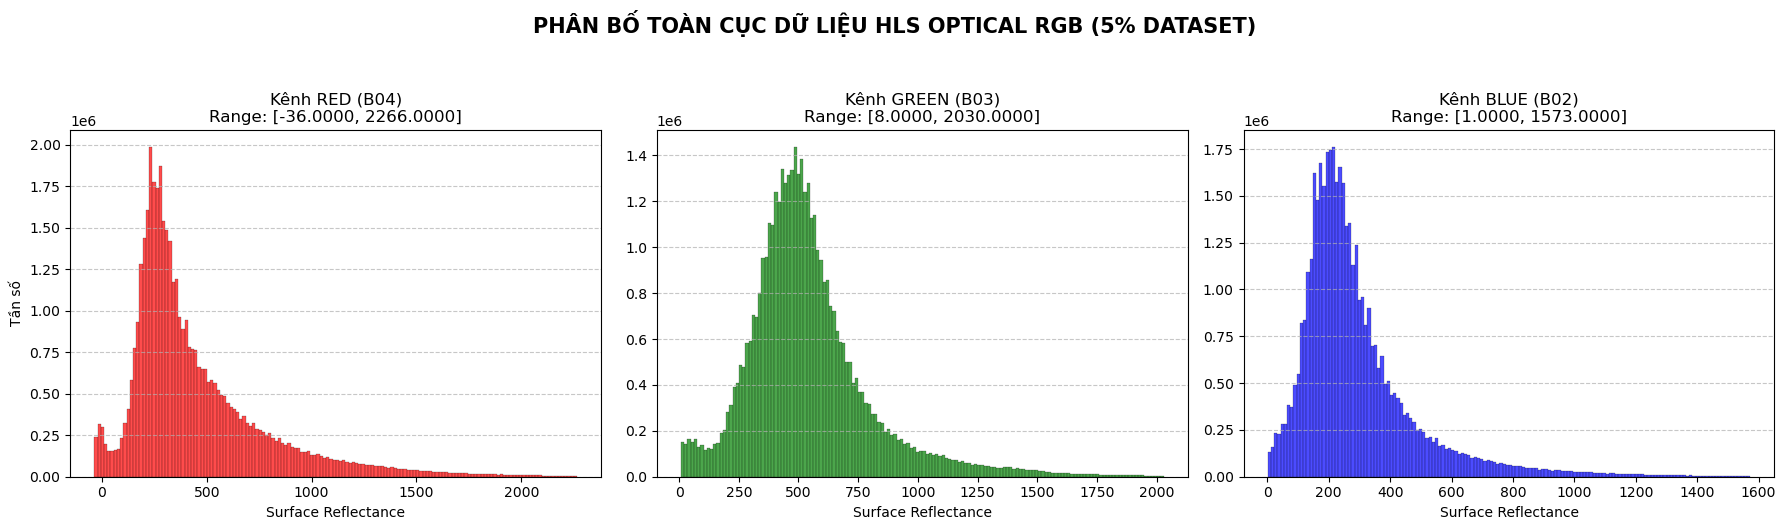

In [16]:
# ==============================================================================
# CELL 5: THỐNG KÊ TOÀN CỤC VÀ HISTOGRAM 5% DATASET (HLS OPTICAL RGB)
# ==============================================================================
import random
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# 1. Cấu hình đường dẫn
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_OPERA/pairs")

print("Đang tìm kiếm toàn bộ ảnh HLS...")
all_hls_files = list(PAIRS_DIR.rglob("*_HLS_*_RGB_aligned.tif"))
total_files = len(all_hls_files)

# Tính toán 5% số lượng ảnh
sample_size = max(1, int(total_files * 0.05))
print(f"Tổng số ảnh HLS: {total_files}. Tiến hành lấy mẫu ngẫu nhiên 5% ({sample_size} ảnh).")

# Lấy ngẫu nhiên 5%
random.seed(42) # Cố định seed
sample_files = random.sample(all_hls_files, sample_size)

# 2. Gom dữ liệu pixel từng kênh (Bỏ qua NaN)
red_list, green_list, blue_list = [], [], []

print("Đang đọc ảnh HLS và trích xuất pixel RGB...")
for f in tqdm(sample_files, desc="Xử lý ảnh HLS"):
    try:
        with rasterio.open(f) as src:
            # Quy ước code tải data: Band 1=B04(Red), Band 2=B03(Green), Band 3=B02(Blue)
            red = src.read(1)
            green = src.read(2)
            blue = src.read(3)
            
            # Lọc bỏ NaN
            valid_red = red[~np.isnan(red)]
            valid_green = green[~np.isnan(green)]
            valid_blue = blue[~np.isnan(blue)]
            
            if valid_red.size > 0: red_list.append(valid_red)
            if valid_green.size > 0: green_list.append(valid_green)
            if valid_blue.size > 0: blue_list.append(valid_blue)
    except Exception as e:
        pass

# Nối mảng 1D
red_all = np.concatenate(red_list)
green_all = np.concatenate(green_list)
blue_all = np.concatenate(blue_list)

# 3. Tính toán các chỉ số thống kê
def print_stats_hls(name, arr):
    print(f"\n--- THỐNG KÊ KÊNH {name} (Trên {len(arr):,} pixels) ---")
    print(f"  Min (Tuyệt đối) : {np.min(arr):.6f}")
    print(f"  Max (Tuyệt đối) : {np.max(arr):.6f}")
    print(f"  Mean (Trung bình): {np.mean(arr):.6f}")
    print(f"  Std (Độ lệch chuẩn): {np.std(arr):.6f}")
    print(f"  Quantiles:")
    print(f"     1% (P1)   : {np.percentile(arr, 1):.6f}")
    print(f"    50% (Med)  : {np.percentile(arr, 50):.6f}")
    print(f"    99% (P99)  : {np.percentile(arr, 99):.6f}")

print_stats_hls("B04 (RED)", red_all)
print_stats_hls("B03 (GREEN)", green_all)
print_stats_hls("B02 (BLUE)", blue_all)

# 4. Vẽ Histogram tổng hợp (3 kênh)
p1_r, p99_r = np.percentile(red_all, 1), np.percentile(red_all, 99)
p1_g, p99_g = np.percentile(green_all, 1), np.percentile(green_all, 99)
p1_b, p99_b = np.percentile(blue_all, 1), np.percentile(blue_all, 99)

plt.figure(figsize=(18, 5))
plt.suptitle('PHÂN BỐ TOÀN CỤC DỮ LIỆU HLS OPTICAL RGB (5% DATASET)', fontsize=15, fontweight='bold', y=1.05)

# Histogram Kênh Đỏ (Red)
plt.subplot(1, 3, 1)
plt.hist(red_all, bins=150, range=(p1_r, p99_r), color='red', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh RED (B04)\nRange: [{p1_r:.4f}, {p99_r:.4f}]', fontsize=12)
plt.xlabel('Surface Reflectance')
plt.ylabel('Tần số')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram Kênh Xanh Lục (Green)
plt.subplot(1, 3, 2)
plt.hist(green_all, bins=150, range=(p1_g, p99_g), color='green', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh GREEN (B03)\nRange: [{p1_g:.4f}, {p99_g:.4f}]', fontsize=12)
plt.xlabel('Surface Reflectance')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Histogram Kênh Xanh Lam (Blue)
plt.subplot(1, 3, 3)
plt.hist(blue_all, bins=150, range=(p1_b, p99_b), color='blue', alpha=0.7, edgecolor='black', linewidth=0.2)
plt.title(f'Kênh BLUE (B02)\nRange: [{p1_b:.4f}, {p99_b:.4f}]', fontsize=12)
plt.xlabel('Surface Reflectance')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

 BỘ CÔNG CỤ NGHIỆM THU VÀ TRÍCH XUẤT TỌA ĐỘ VỆ TINH
1. Đang quét tìm các thư mục mẫu trong /mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs...
   -> Đã tìm thấy 1579 thư mục mẫu (Bao gồm cả rỗng).

2. Đang phân tích file và trích xuất tọa độ không gian...


Nghiệm thu: 100%|██████████| 1579/1579 [00:07<00:00, 213.46it/s]



 BÁO CÁO THỐNG KÊ TỔNG QUAN
Tổng số thư mục được quét : 1579
Thư mục RỖNG (Null)       : 334 (Lỗi mạng hoặc không tìm thấy ảnh)
Thư mục HỢP LỆ (Có ảnh)   : 1245

--- THỐNG KÊ THEO TẬP DỮ LIỆU (TRAIN/VAL/TEST) ---
  Set  Số_Mẫu  Tổng_HLS  Tổng_OPERA
 test     145       145         682
train     995       995        4778
  val     105       105         519

3. Đang xuất file Excel tọa độ...
    Đã lưu tọa độ Bounding Box của 1245 khu vực hợp lệ tại:
    /mnt/hdd12tb/code/thucnd/Stat_data/S1_S2_Download_Targets.xlsx

4. Đang vẽ biểu đồ tần số...
    Đã lưu biểu đồ tại:
    /mnt/hdd12tb/code/thucnd/Stat_data/OPERA_HLS_Ratio_Histogram.png


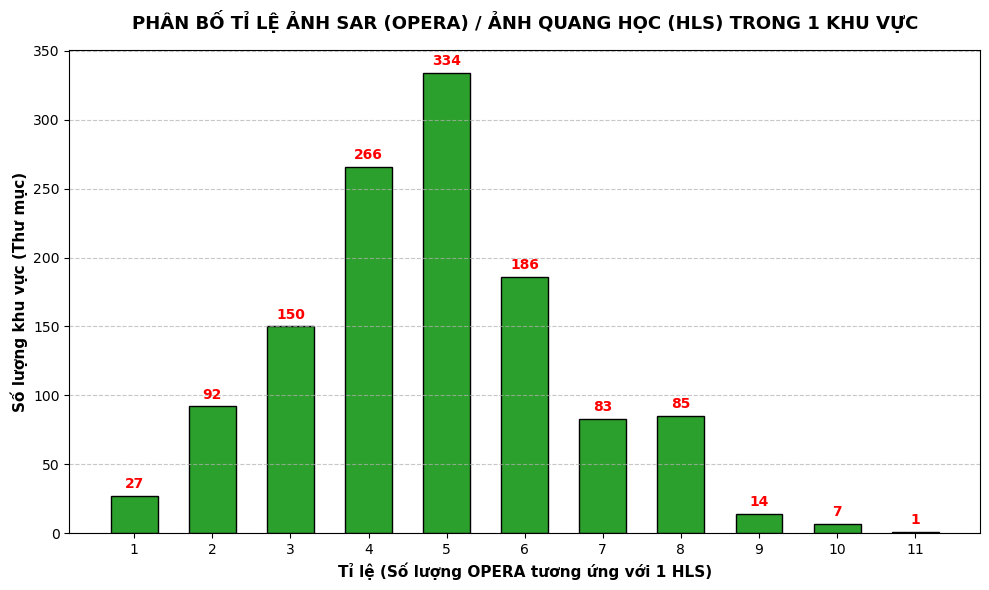

In [10]:
import os
import pandas as pd
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
from collections import Counter

# ==========================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==========================================
# Đã cập nhật đường dẫn PAIRS_DIR theo đúng log lỗi của bạn
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs")
OUTPUT_EXCEL = Path("/mnt/hdd12tb/code/thucnd/Stat_data/S1_S2_Download_Targets.xlsx")
OUTPUT_HISTOGRAM = Path("/mnt/hdd12tb/code/thucnd/Stat_data/OPERA_HLS_Ratio_Histogram.png")

MAX_WORKERS = 16

# ==========================================
# 2. HÀM XỬ LÝ CHO TỪNG THƯ MỤC
# ==========================================
def audit_single_folder(folder_path):
    """
    Quét 1 thư mục mẫu: Đếm số ảnh HLS, OPERA, và trích xuất tọa độ địa lý.
    """
    hls_files = list(folder_path.glob("*_HLS_*_RGB_aligned.tif"))
    op_files = list(folder_path.glob("*_OP_*_VVVH_aligned.tif"))
    
    hls_count = len(hls_files)
    op_count = len(op_files)
    
    # Xác định thư mục này thuộc tập train, val hay test bằng cách kiểm tra đường dẫn cha
    dataset_set = "unknown"
    for part in folder_path.parts:
        if part.lower() in ['train', 'val', 'test']:
            dataset_set = part.lower()
            break

    result = {
        "Folder_Name": folder_path.name,
        "Set": dataset_set,
        "HLS_Count": hls_count,
        "OPERA_Count": op_count,
        "Is_Null": (hls_count == 0 and op_count == 0),
        "Ratio_OP_HLS": (op_count / hls_count) if hls_count > 0 else 0,
        "Min_Lon": None, "Min_Lat": None, 
        "Max_Lon": None, "Max_Lat": None,
        "Center_Lon": None, "Center_Lat": None
    }
    
    # Nếu thư mục có dữ liệu, mở 1 file TIF bất kỳ để lấy Bounding Box thực tế
    if hls_count > 0 or op_count > 0:
        sample_tif = hls_files[0] if hls_count > 0 else op_files[0]
        try:
            with rasterio.open(sample_tif) as src:
                bounds = src.bounds
                crs = src.crs
                # Chuyển đổi Bounding Box từ UTM (Hệ mét) về lại WGS84 (Kinh/Vĩ độ)
                min_lon, min_lat, max_lon, max_lat = transform_bounds(crs, "EPSG:4326", *bounds)
                
                result["Min_Lon"] = round(min_lon, 6)
                result["Min_Lat"] = round(min_lat, 6)
                result["Max_Lon"] = round(max_lon, 6)
                result["Max_Lat"] = round(max_lat, 6)
                result["Center_Lon"] = round((min_lon + max_lon) / 2.0, 6)
                result["Center_Lat"] = round((min_lat + max_lat) / 2.0, 6)
        except Exception:
            pass # Bỏ qua nếu file lỗi

    return result

# ==========================================
# 3. LUỒNG THỰC THI CHÍNH
# ==========================================
if __name__ == "__main__":
    print("=====================================================")
    print(" BỘ CÔNG CỤ NGHIỆM THU VÀ TRÍCH XUẤT TỌA ĐỘ VỆ TINH")
    print("=====================================================")

    print(f"1. Đang quét tìm các thư mục mẫu trong {PAIRS_DIR}...")
    
    sample_folders = set()
    
    # Lặp qua tất cả đường dẫn an toàn hơn list comprehension
    for d in PAIRS_DIR.rglob("*"):
        if d.is_dir():
            # Bỏ qua các thư mục gốc/trung gian
            if d.name in ['train', 'val', 'test'] or d.name.startswith('Pix2Pix'):
                continue
            
            # Một thư mục được xem là thư mục mẫu nếu nó KHÔNG chứa thư mục con nào khác
            # (Tức là nó nằm ở tầng sâu nhất, chỉ chứa file ảnh hoặc rỗng)
            has_subdir = any(sub.is_dir() for sub in d.iterdir())
            if not has_subdir:
                sample_folders.add(d)

    sample_folders = list(sample_folders)
    print(f"   -> Đã tìm thấy {len(sample_folders)} thư mục mẫu (Bao gồm cả rỗng).\n")

    print("2. Đang phân tích file và trích xuất tọa độ không gian...")
    results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(audit_single_folder, folder): folder for folder in sample_folders}
        for future in tqdm(as_completed(futures), total=len(sample_folders), desc="Nghiệm thu"):
            results.append(future.result())

    df = pd.DataFrame(results)

    # ==========================================
    # 4. THỐNG KÊ VÀ BÁO CÁO (TERMINAL)
    # ==========================================
    total_dirs = len(df)
    null_dirs = df[df['Is_Null'] == True]
    valid_dirs = df[df['Is_Null'] == False]

    print("\n=====================================================")
    print(" BÁO CÁO THỐNG KÊ TỔNG QUAN")
    print("=====================================================")
    print(f"Tổng số thư mục được quét : {total_dirs}")
    print(f"Thư mục RỖNG (Null)       : {len(null_dirs)} (Lỗi mạng hoặc không tìm thấy ảnh)")
    print(f"Thư mục HỢP LỆ (Có ảnh)   : {len(valid_dirs)}")
    
    print("\n--- THỐNG KÊ THEO TẬP DỮ LIỆU (TRAIN/VAL/TEST) ---")
    if not valid_dirs.empty:
        stats_by_set = valid_dirs.groupby('Set').agg(
            Số_Mẫu=('Folder_Name', 'count'),
            Tổng_HLS=('HLS_Count', 'sum'),
            Tổng_OPERA=('OPERA_Count', 'sum')
        ).reset_index()
        print(stats_by_set.to_string(index=False))
    
    # ==========================================
    # 5. XUẤT FILE EXCEL ĐỂ TẢI SENTINEL 1 & 2
    # ==========================================
    if not valid_dirs.empty:
        print("\n3. Đang xuất file Excel tọa độ...")
        # Lọc các cột cần thiết cho việc tải dữ liệu sau này
        export_df = valid_dirs[['Folder_Name', 'Set', 'Min_Lon', 'Min_Lat', 'Max_Lon', 'Max_Lat', 'Center_Lon', 'Center_Lat']]
        export_df = export_df.sort_values(by=['Set', 'Folder_Name'])
        export_df.to_excel(OUTPUT_EXCEL, index=False)
        print(f"    Đã lưu tọa độ Bounding Box của {len(valid_dirs)} khu vực hợp lệ tại:")
        print(f"    {OUTPUT_EXCEL}")

    # ==========================================
    # 6. VẼ BIỂU ĐỒ HISTOGRAM TỈ LỆ OPERA / HLS
    # ==========================================
    if not valid_dirs.empty:
        print("\n4. Đang vẽ biểu đồ tần số...")
        ratios = valid_dirs['Ratio_OP_HLS']
        
        plt.figure(figsize=(10, 6))
        
        # Đếm tần số của các tỷ lệ (Ví dụ: 1 HLS đi với 1, 2, 3... OPERA)
        ratio_counts = Counter(ratios)
        x_vals = sorted(ratio_counts.keys())
        y_vals = [ratio_counts[x] for x in x_vals]
        
        bars = plt.bar([str(int(x)) if x.is_integer() else str(x) for x in x_vals], y_vals, color='#2ca02c', edgecolor='black', width=0.6)
        
        plt.title('PHÂN BỐ TỈ LỆ ẢNH SAR (OPERA) / ẢNH QUANG HỌC (HLS) TRONG 1 KHU VỰC', fontsize=13, fontweight='bold', pad=15)
        plt.xlabel('Tỉ lệ (Số lượng OPERA tương ứng với 1 HLS)', fontsize=11, fontweight='bold')
        plt.ylabel('Số lượng khu vực (Thư mục)', fontsize=11, fontweight='bold')
        
        # Ghi chú con số lên đỉnh cột
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + (max(y_vals)*0.01), 
                     int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')
                     
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(OUTPUT_HISTOGRAM, dpi=300)
        print(f"    Đã lưu biểu đồ tại:")
        print(f"    {OUTPUT_HISTOGRAM}")
        
    print("=====================================================")

 BẮT ĐẦU QUÉT TỶ LỆ NULL DATA TRÊN TOÀN BỘ TẬP DỮ LIỆU

-> Tìm thấy tổng cộng 7224 file .tif. Đang tính toán...


Quét Null Data: 100%|██████████| 7224/7224 [00:19<00:00, 373.71it/s]  



✅ Đã quét xong! Có 109 ảnh HLS và 2105 ảnh OPERA chứa Null Data.

--- HIỂN THỊ TOP 5 ẢNH HLS (QUANG HỌC) BỊ KHUYẾT NHIỀU NHẤT ---


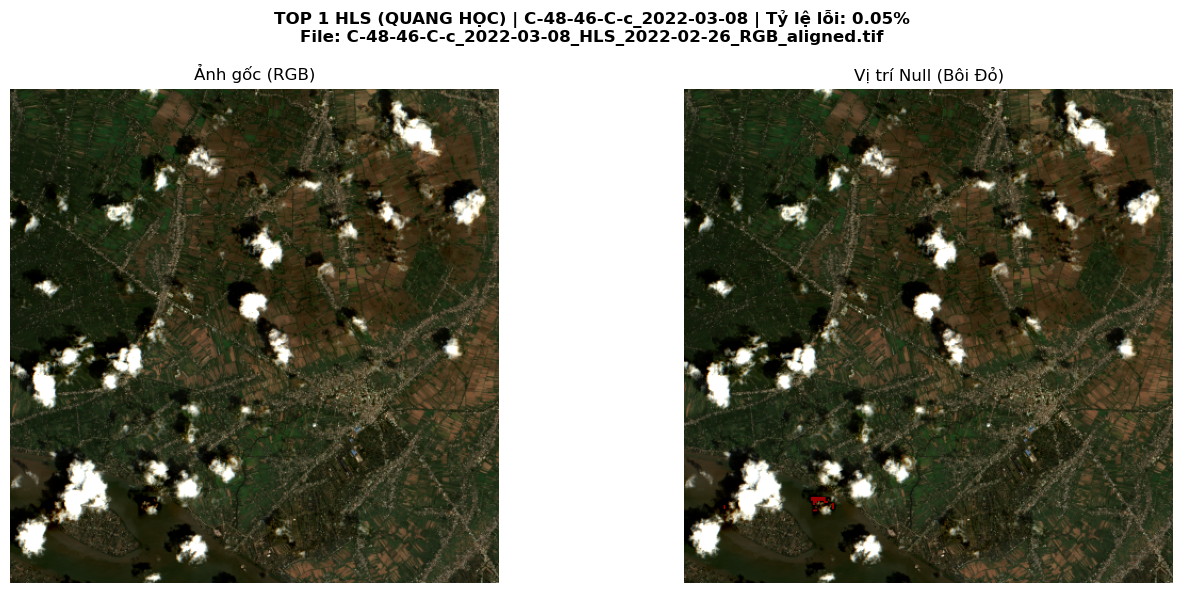

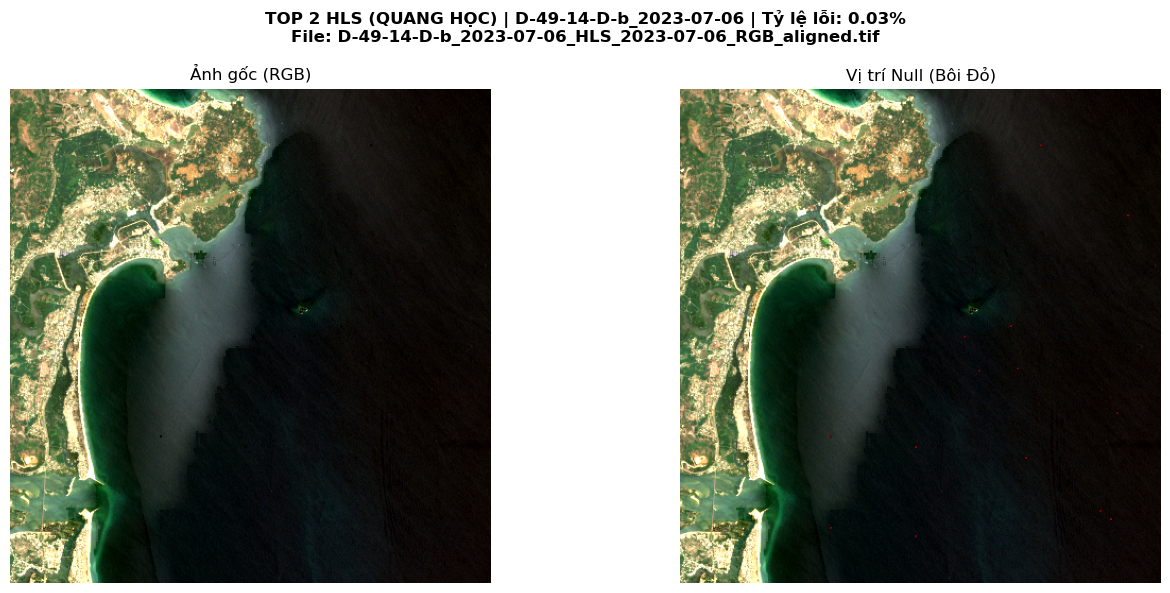

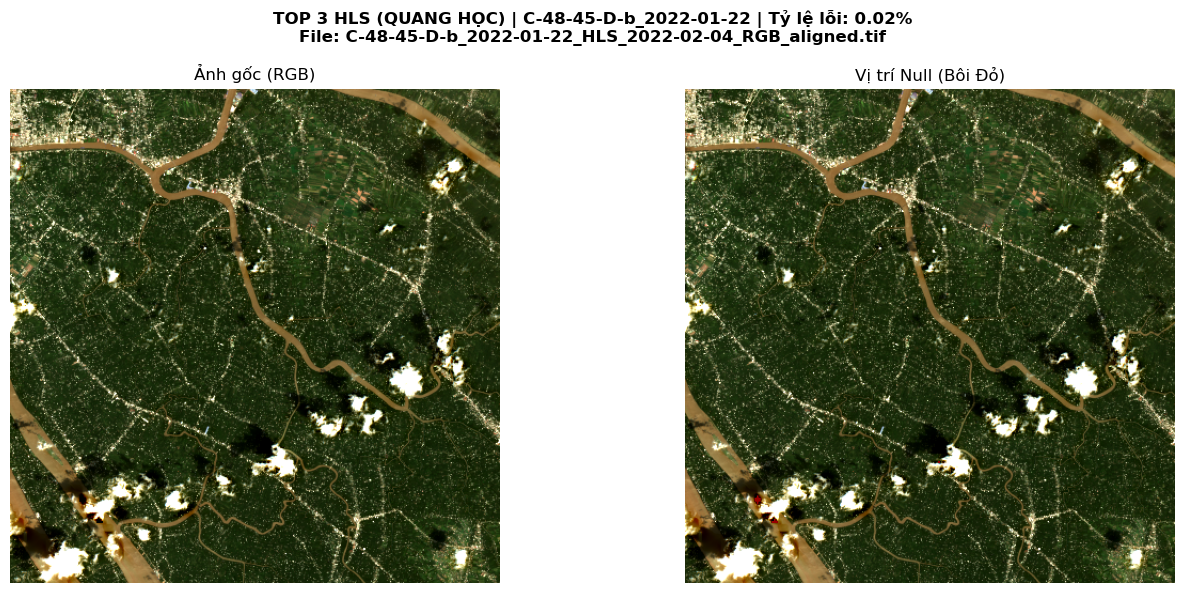

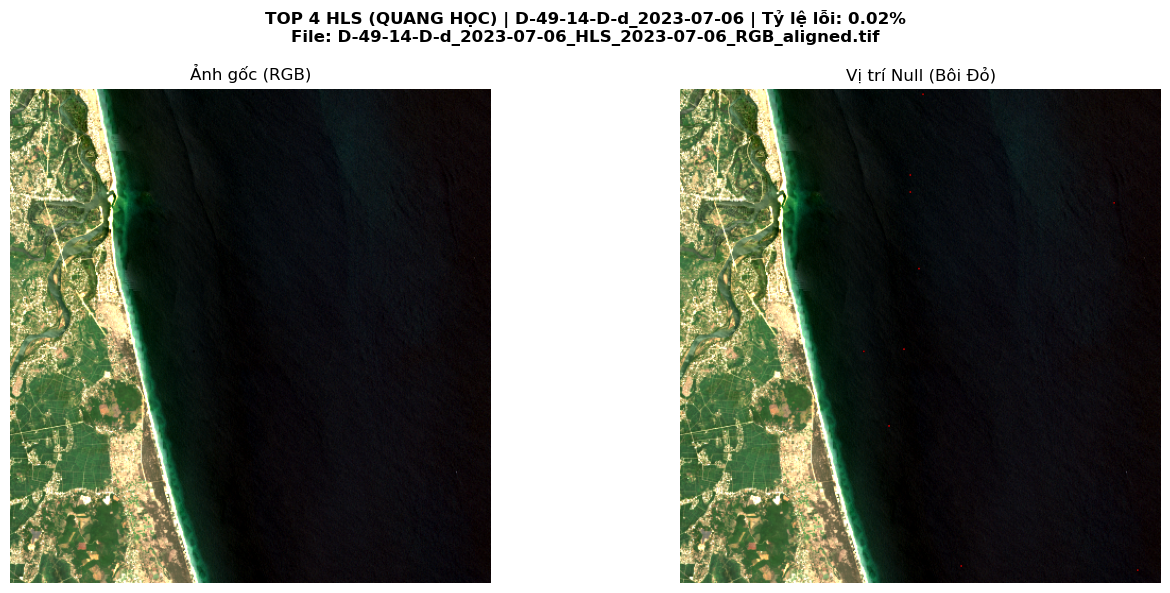

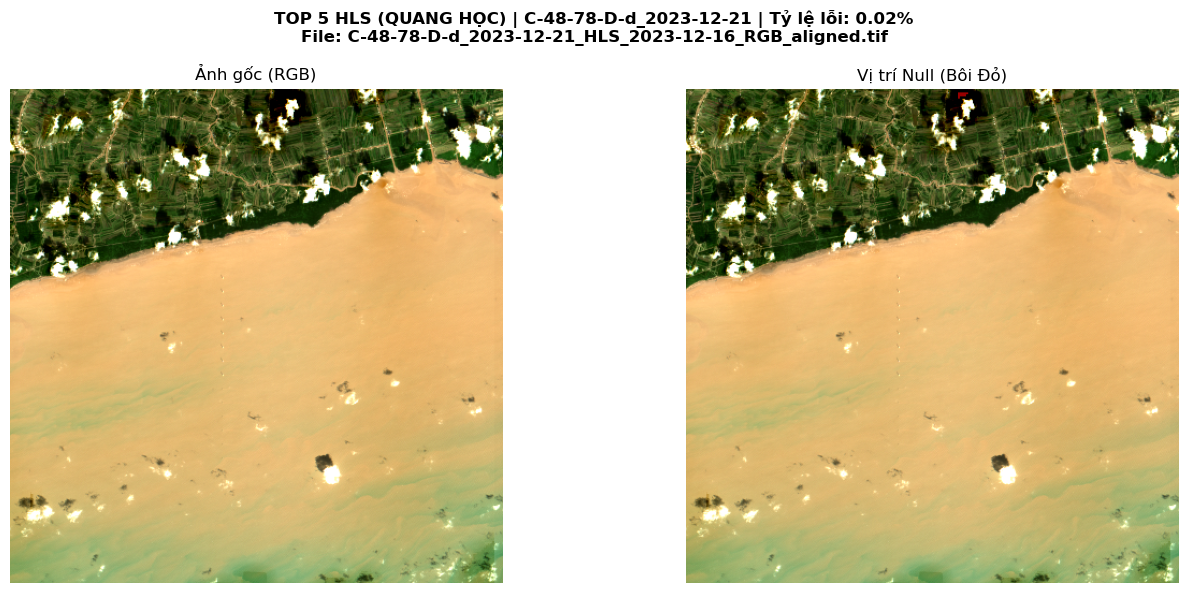


--- HIỂN THỊ TOP 5 ẢNH OPERA (SAR) BỊ KHUYẾT NHIỀU NHẤT ---


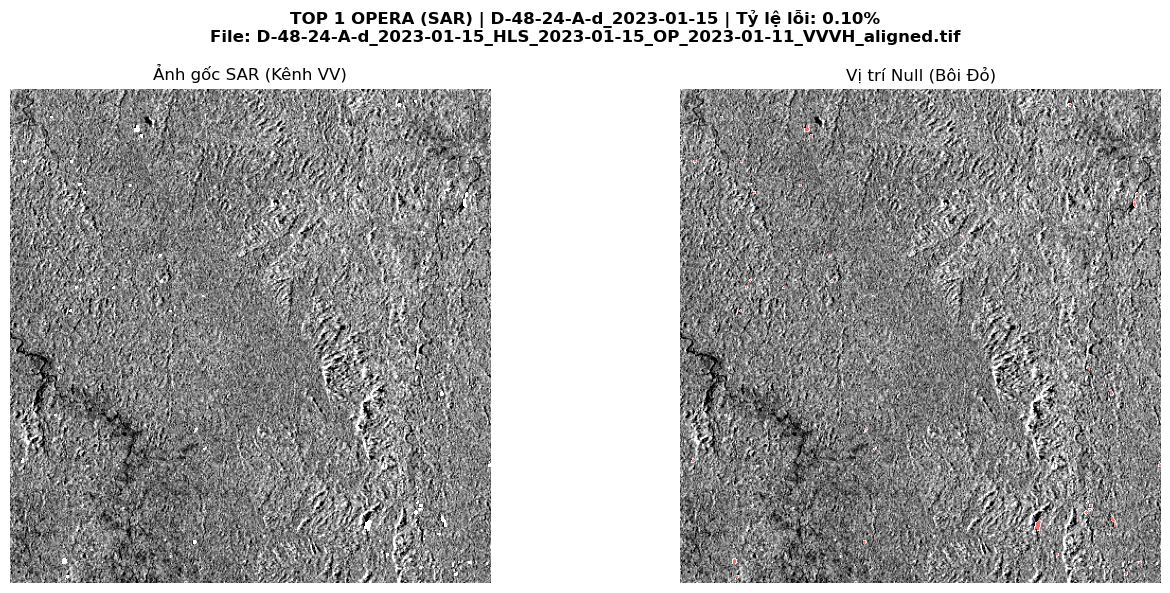

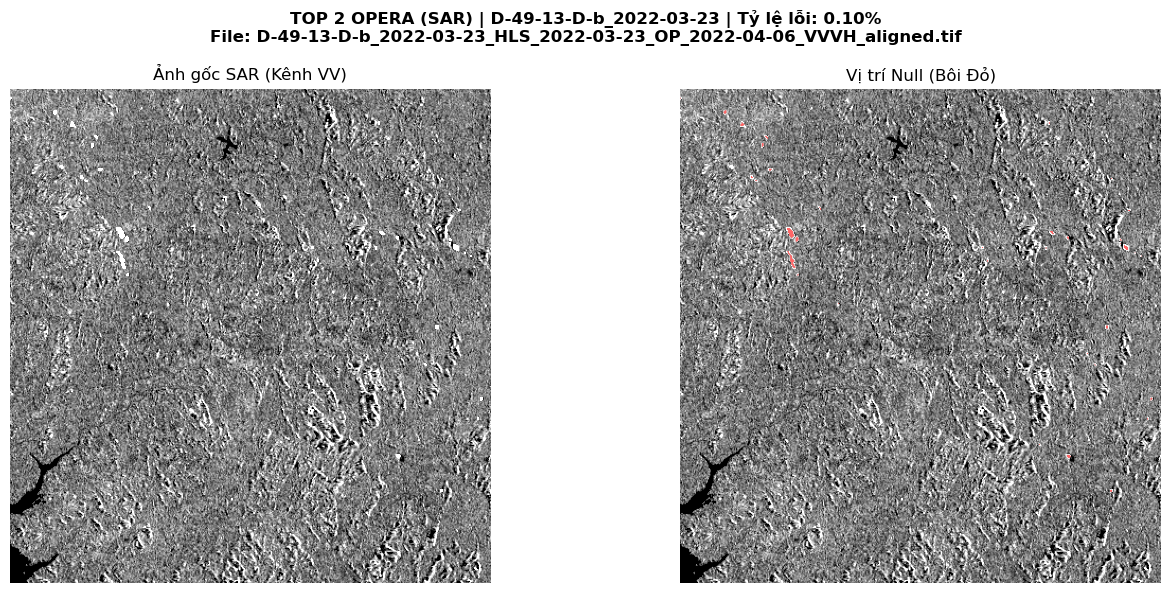

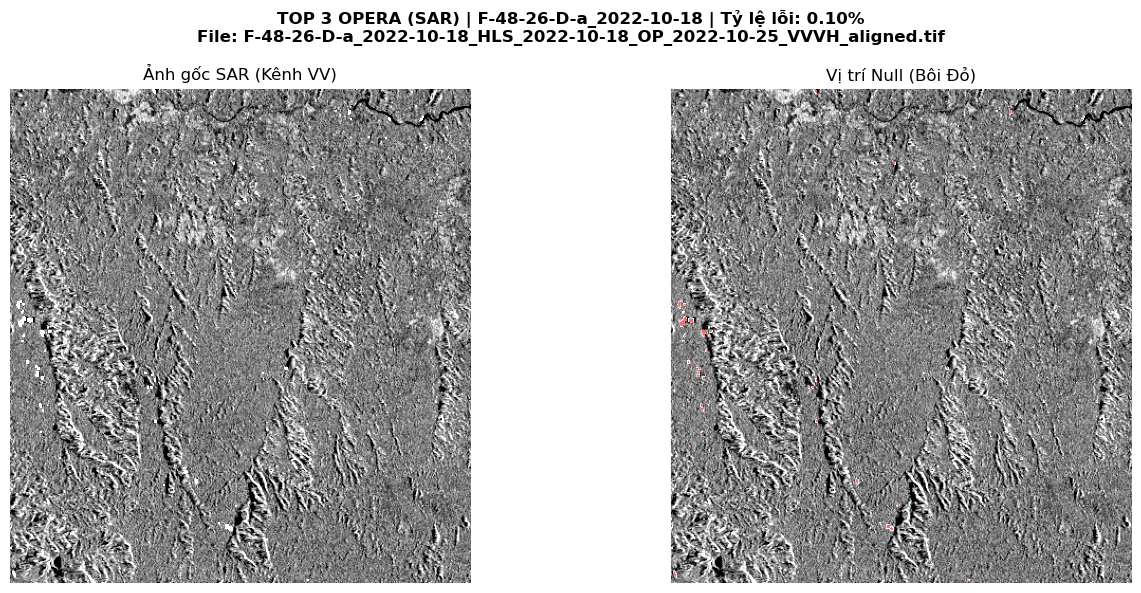

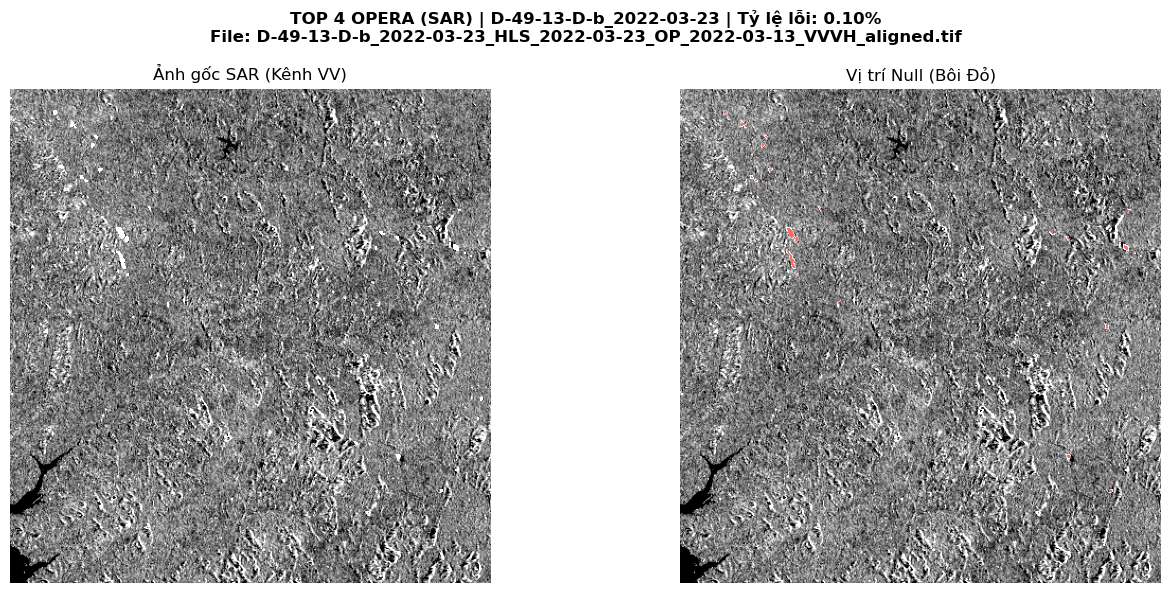

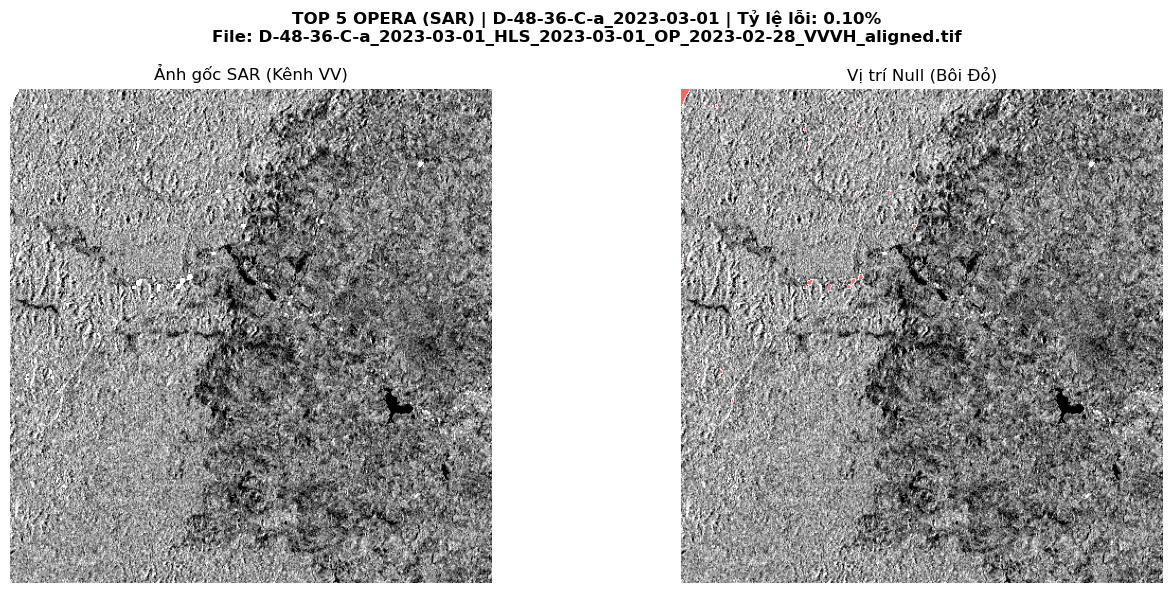

In [11]:
# ==============================================================================
# CELL: RÀ SOÁT VÀ TRỰC QUAN HÓA VỊ TRÍ NULL DATA (MISSING PIXELS)
# ==============================================================================
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings

# Bỏ qua cảnh báo chia cho 0 hoặc tính toán trên mảng toàn NaN
warnings.filterwarnings("ignore")

# 1. Cấu hình đường dẫn
PAIRS_DIR = Path("/mnt/hdd12tb/code/thucnd/Data_HLS_opera_2/pairs")
MAX_WORKERS = 16

def check_null_ratio(filepath):
    """Đọc ảnh và tính tỷ lệ phần trăm pixel bị NaN"""
    try:
        with rasterio.open(filepath) as src:
            arr = src.read()
            # Một pixel bị coi là Null nếu BẤT KỲ kênh nào của nó bị NaN
            null_mask = np.any(np.isnan(arr), axis=0)
            
            total_pixels = null_mask.size
            null_pixels = np.sum(null_mask)
            ratio = null_pixels / total_pixels
            
            img_type = "HLS" if "RGB" in filepath.name else "OPERA"
            return {"path": filepath, "ratio": ratio, "type": img_type}
    except Exception as e:
        return None

if __name__ == "__main__":
    print("=========================================================")
    print(" BẮT ĐẦU QUÉT TỶ LỆ NULL DATA TRÊN TOÀN BỘ TẬP DỮ LIỆU")
    print("=========================================================\n")

    # Tìm tất cả file TIF
    all_tifs = list(PAIRS_DIR.rglob("*.tif"))
    print(f"-> Tìm thấy tổng cộng {len(all_tifs)} file .tif. Đang tính toán...")

    results = []
    # Quét đa luồng cho nhanh
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(check_null_ratio, f): f for f in all_tifs}
        for future in tqdm(as_completed(futures), total=len(all_tifs), desc="Quét Null Data"):
            res = future.result()
            if res is not None:
                # Chỉ quan tâm những ảnh có tỷ lệ khuyết > 0%
                if res['ratio'] > 0.0:
                    results.append(res)

    # Phân loại và sắp xếp giảm dần theo tỷ lệ Null
    hls_nulls = sorted([r for r in results if r['type'] == 'HLS'], key=lambda x: x['ratio'], reverse=True)
    op_nulls = sorted([r for r in results if r['type'] == 'OPERA'], key=lambda x: x['ratio'], reverse=True)

    print(f"\n✅ Đã quét xong! Có {len(hls_nulls)} ảnh HLS và {len(op_nulls)} ảnh OPERA chứa Null Data.")
    
    # ==========================================
    # HÀM VẼ ẢNH VÀ MẶT NẠ ĐỎ (RED OVERLAY)
    # ==========================================
    def plot_top_nulls(top_files, title_prefix):
        if not top_files:
            print(f"Không có ảnh {title_prefix} nào bị khuyết dữ liệu!")
            return
            
        print(f"\n--- HIỂN THỊ TOP {len(top_files)} ẢNH {title_prefix} BỊ KHUYẾT NHIỀU NHẤT ---")
        
        for i, item in enumerate(top_files):
            filepath = item['path']
            ratio = item['ratio']
            
            with rasterio.open(filepath) as src:
                arr = src.read()
            
            # Tạo mặt nạ Null (True ở những nơi bị khuyết)
            mask = np.any(np.isnan(arr), axis=0)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
            fig.suptitle(f"TOP {i+1} {title_prefix} | {filepath.parent.name} | Tỷ lệ lỗi: {ratio*100:.2f}%\nFile: {filepath.name}", fontsize=12, fontweight='bold')

            # --- VẼ ẢNH NỀN ---
            if np.all(mask):
                # Nếu ảnh hỏng 100% (toàn là NaN)
                ax1.text(0.5, 0.5, 'ẢNH RỖNG 100% (ALL NaN)', horizontalalignment='center', verticalalignment='center', fontsize=15, color='red')
                ax2.text(0.5, 0.5, 'ẢNH RỖNG 100% (ALL NaN)', horizontalalignment='center', verticalalignment='center', fontsize=15, color='red')
                ax1.set_facecolor('black')
                ax2.set_facecolor('black')
            else:
                if item['type'] == 'HLS':
                    # Vẽ HLS (RGB)
                    img = np.moveaxis(arr[:3], 0, -1)
                    p2, p98 = np.nanpercentile(img, (2, 98))
                    img_display = np.clip((img - p2) / (p98 - p2 + 1e-5), 0, 1)
                    # Chỗ nào NaN ép thành màu đen để dễ nhìn ảnh gốc
                    img_display[mask] = 0 
                    
                    ax1.imshow(img_display)
                    ax1.set_title("Ảnh gốc (RGB)")
                    ax2.imshow(img_display)
                else:
                    # Vẽ OPERA (Kênh VV)
                    vv = arr[0]
                    # Chuyển dB và kéo dải màu
                    vv_db = 10 * np.log10(np.maximum(vv, 1e-7))
                    p2, p98 = np.nanpercentile(vv_db, (2, 98))
                    
                    # Tạo ảnh display xám
                    ax1.imshow(vv_db, cmap='gray', vmin=p2, vmax=p98)
                    ax1.set_title("Ảnh gốc SAR (Kênh VV)")
                    ax2.imshow(vv_db, cmap='gray', vmin=p2, vmax=p98)

                # --- VẼ MẶT NẠ ĐỎ (RED OVERLAY) VÀO TRỤC 2 ---
                # Tạo một ma trận màu đỏ RGBA
                red_overlay = np.zeros((*mask.shape, 4))
                red_overlay[mask, 0] = 1.0 # Kênh Đỏ (Red) = Max
                red_overlay[mask, 3] = 0.6 # Kênh Alpha (Độ trong suốt) = 60%
                
                ax2.imshow(red_overlay)
                ax2.set_title("Vị trí Null (Bôi Đỏ)")

            # Tắt hiển thị trục tọa độ cho đẹp
            ax1.axis('off')
            ax2.axis('off')
            plt.tight_layout()
            plt.show()

    # Lấy Top 5 ảnh khuyết nhiều nhất (bạn có thể đổi số 5 thành 10 nếu muốn xem thêm)
    top_5_hls = hls_nulls[:5]
    top_5_op = op_nulls[:5]

    plot_top_nulls(top_5_hls, "HLS (QUANG HỌC)")
    plot_top_nulls(top_5_op, "OPERA (SAR)")